# Exercise 1

### Part 1

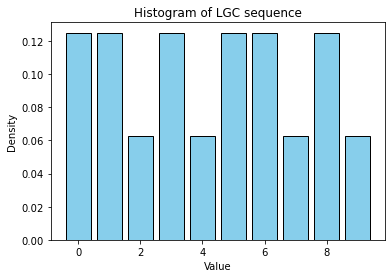

In [1]:
import matplotlib.pyplot as plt
def LCG(x0, a, c, M, N):
    seq = []
    for _ in range(0, N-1):
        x = (a*x0 + c) % M
        x0 = x
        U = x/M
        seq.append(U)
    return seq

seq = LCG(3, 5, 1, 16, 10000)

counts = []
for i in range(10):
    count = sum(1 for x in seq if i/10 <= x < (i+1)/10)
    counts.append(count)
counts = [count/sum(counts) for count in counts]

plt.bar(range(10), counts, width=0.8, color="skyblue", edgecolor="black")
plt.title('Histogram of LGC sequence')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

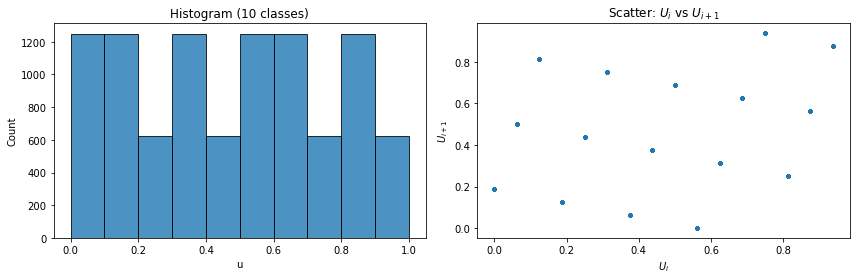

=== Chi-square (Uniform, 10 classes) ===
T = 937.0946, df = 9, p-value = 0
Observed counts: [1249, 1250, 625, 1250, 625, 1250, 1250, 625, 1250, 625]

=== Kolmogorov-Smirnov (Uniform) ===
D = 0.0625, p-value = 2.09649e-34

=== Runs test (above/below 0.5) ===
runs = 3750, z = -25.0125, p-value = 0


In [2]:
import numpy as np
from scipy.stats import chi2, kstest, norm

def chi_square_uniform_test(u, k=10):
    n = len(u)
    edges = np.linspace(0, 1, k + 1)
    obs, _ = np.histogram(u, bins=edges)
    exp = np.full(k, n / k)
    T = np.sum((obs - exp) ** 2 / exp)
    df = k - 1
    p = 1 - chi2.cdf(T, df)
    return T, df, p, obs, exp

def runs_test_above_below_median(u):
    signs = (u >= 0.5).astype(int)
    n1 = np.sum(signs == 1)
    n2 = np.sum(signs == 0)

    runs = 1 + np.sum(signs[1:] != signs[:-1])

    mu = (2 * n1 * n2) / (n1 + n2) + 1
    var = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2) ** 2) * (n1 + n2 - 1))
    z = (runs - mu) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return runs, z, p

N = 10_000
u = np.array(LCG(x0=1, a=5, c=3, M=16, N=N))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(u, bins=10, range=(0, 1), edgecolor='black', alpha=0.8)
ax[0].set_title("Histogram (10 classes)")
ax[0].set_xlabel("u")
ax[0].set_ylabel("Count")

ax[1].scatter(u[:-1], u[1:], s=8, alpha=0.35)
ax[1].set_title("Scatter: $U_i$ vs $U_{i+1}$")
ax[1].set_xlabel("$U_i$")
ax[1].set_ylabel("$U_{i+1}$")

plt.tight_layout()
plt.show()

T, df, p_chi2, obs, exp = chi_square_uniform_test(u, k=10)

D, p_ks = kstest(u, 'uniform')

runs, z_runs, p_runs = runs_test_above_below_median(u)

print("=== Chi-square (Uniform, 10 classes) ===")
print(f"T = {T:.4f}, df = {df}, p-value = {p_chi2:.6g}")
print("Observed counts:", obs.tolist())

print("\n=== Kolmogorov-Smirnov (Uniform) ===")
print(f"D = {D:.4f}, p-value = {p_ks:.6g}")

print("\n=== Runs test (above/below 0.5) ===")
print(f"runs = {runs}, z = {z_runs:.4f}, p-value = {p_runs:.6g}")

In [3]:
import numpy as np
from scipy.stats import chi2, kstest, norm

def chi_square_uniform_test(u, k=10):
    n = len(u)
    edges = np.linspace(0, 1, k + 1)
    obs, _ = np.histogram(u, bins=edges)
    exp = np.full(k, n / k)
    T = np.sum((obs - exp) ** 2 / exp)
    df = k - 1
    p = 1 - chi2.cdf(T, df)
    return T, df, p, obs, exp

def runs_test_above_below_median(u):
    signs = (u >= 0.5).astype(int)
    n1 = np.sum(signs == 1)
    n2 = np.sum(signs == 0)

    runs = 1 + np.sum(signs[1:] != signs[:-1])

    mu = (2 * n1 * n2) / (n1 + n2) + 1
    var = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2) ** 2) * (n1 + n2 - 1))
    z = (runs - mu) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return runs, z, p

def lag_correlation_tests(u, h_values=(1, 2, 5, 10)):
    n = len(u)
    out = []
    for h in h_values:
        x = u[:-h]
        y = u[h:]
        r = np.corrcoef(x, y)[0, 1]
        z = r * np.sqrt(n - h)
        p = 2 * (1 - norm.cdf(abs(z)))
        out.append((h, r, z, p))
    return out

# ---- Generate and evaluate ----
def run_LCG_variations(x0, a, c, M, N):
    u = np.array(LCG(x0=x0, a=a, c=c, M=M, N=N))
    T, df, p_chi2, obs, exp = chi_square_uniform_test(u, k=10)

    D, p_ks = kstest(u, 'uniform')

    runs, z_runs, p_runs = runs_test_above_below_median(u)

    corr_results = lag_correlation_tests(u, h_values=(1, 2, 5, 10, 20))
    if p_chi2 > 0.05 and p_ks > 0.05 and p_runs > 0.05 and all(p > 0.05 for _, _, _, p in corr_results):
        return a, c, M
    
N = 10_000
A = [0,1,2,3,4,5,6,7,8,9, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
C = [0,1,2,3,4,5,6,7,8,9, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
M_list = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
for a in A:
    for c in C:
        for M in M_list:
            result = run_LCG_variations(x0=1, a=a, c=c, M=M, N=N)
            if result is not None:
                print(f"Found good parameters: a={result[0]}, c={result[1]}, M={result[2]}")

<ipython-input-3-45822aca56b0>:23: RuntimeWarning: invalid value encountered in double_scalars
  z = (runs - mu) / np.sqrt(var)
/Users/tanne/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/function_base.py:2829: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/Users/tanne/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/function_base.py:2830: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


Found good parameters: a=17, c=47, M=256
Found good parameters: a=37, c=11, M=1024
Found good parameters: a=37, c=23, M=1024
Found good parameters: a=37, c=37, M=512
Found good parameters: a=37, c=37, M=1024
Found good parameters: a=37, c=47, M=1024
Found good parameters: a=41, c=9, M=512
Found good parameters: a=41, c=11, M=512
Found good parameters: a=41, c=11, M=1024
Found good parameters: a=41, c=13, M=1024
Found good parameters: a=41, c=17, M=1024
Found good parameters: a=41, c=19, M=1024
Found good parameters: a=41, c=23, M=1024
Found good parameters: a=41, c=29, M=512
Found good parameters: a=41, c=29, M=1024
Found good parameters: a=41, c=31, M=512
Found good parameters: a=43, c=0, M=1024


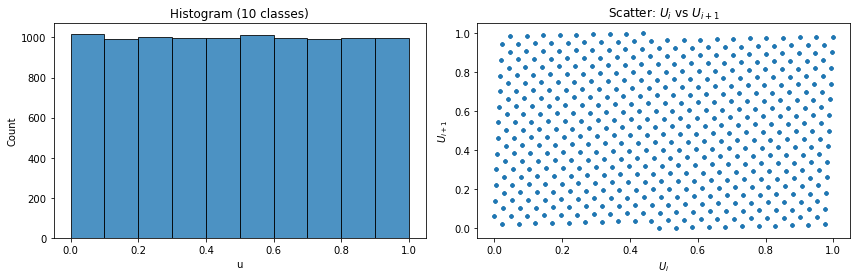

=== Chi-square (Uniform, 10 classes) ===
T = 0.6930, df = 9, p-value = 0.999878
Observed counts: [1019, 993, 1002, 996, 997, 1011, 998, 990, 995, 998]

=== Kolmogorov-Smirnov (Uniform) ===
D = 0.0029, p-value = 0.999996

=== Runs test (above/below 0.5) ===
runs = 5041, z = 0.8103, p-value = 0.417763

=== Lag correlation tests ===
h= 1: r=+0.00635, z=+0.635, p-value=0.525302
h= 2: r=-0.00389, z=-0.389, p-value=0.697308
h= 5: r=+0.00355, z=+0.355, p-value=0.722403
h=10: r=+0.01001, z=+1.000, p-value=0.31729
h=20: r=-0.00372, z=-0.371, p-value=0.710389


In [4]:
import numpy as np
from scipy.stats import chi2, kstest, norm

def chi_square_uniform_test(u, k=10):
    n = len(u)
    edges = np.linspace(0, 1, k + 1)
    obs, _ = np.histogram(u, bins=edges)
    exp = np.full(k, n / k)
    T = np.sum((obs - exp) ** 2 / exp)
    df = k - 1
    p = 1 - chi2.cdf(T, df)
    return T, df, p, obs, exp

def runs_test_above_below_median(u):
    signs = (u >= 0.5).astype(int)
    n1 = np.sum(signs == 1)
    n2 = np.sum(signs == 0)

    runs = 1 + np.sum(signs[1:] != signs[:-1])

    mu = (2 * n1 * n2) / (n1 + n2) + 1
    var = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2) ** 2) * (n1 + n2 - 1))
    z = (runs - mu) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return runs, z, p

def lag_correlation_tests(u, h_values=(1, 2, 5, 10)):
    n = len(u)
    out = []
    for h in h_values:
        x = u[:-h]
        y = u[h:]
        r = np.corrcoef(x, y)[0, 1]
        z = r * np.sqrt(n - h)
        p = 2 * (1 - norm.cdf(abs(z)))
        out.append((h, r, z, p))
    return out

# ---- Generate and evaluate ----
N = 10_000
a=41
c=31
M=512
u = np.array(LCG(x0=1, a=a, c=c, M=M, N=N))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(u, bins=10, range=(0, 1), edgecolor='black', alpha=0.8)
ax[0].set_title("Histogram (10 classes)")
ax[0].set_xlabel("u")
ax[0].set_ylabel("Count")

ax[1].scatter(u[:-1], u[1:], s=8, alpha=0.35)
ax[1].set_title("Scatter: $U_i$ vs $U_{i+1}$")
ax[1].set_xlabel("$U_i$")
ax[1].set_ylabel("$U_{i+1}$")

plt.tight_layout()
plt.show()

T, df, p_chi2, obs, exp = chi_square_uniform_test(u, k=10)

D, p_ks = kstest(u, 'uniform')

runs, z_runs, p_runs = runs_test_above_below_median(u)

corr_results = lag_correlation_tests(u, h_values=(1, 2, 5, 10, 20))

print("=== Chi-square (Uniform, 10 classes) ===")
print(f"T = {T:.4f}, df = {df}, p-value = {p_chi2:.6g}")
print("Observed counts:", obs.tolist())

print("\n=== Kolmogorov-Smirnov (Uniform) ===")
print(f"D = {D:.4f}, p-value = {p_ks:.6g}")

print("\n=== Runs test (above/below 0.5) ===")
print(f"runs = {runs}, z = {z_runs:.4f}, p-value = {p_runs:.6g}")

print("\n=== Lag correlation tests ===")
for h, r, z, p in corr_results:
    print(f"h={h:>2}: r={r:+.5f}, z={z:+.3f}, p-value={p:.6g}")

### Part 2

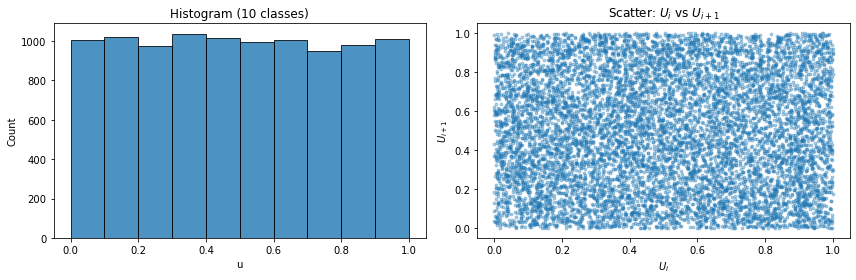

=== Chi-square (Uniform, 10 classes) ===
T = 5.8720, df = 9, p-value = 0.752658
Observed counts: [1004, 1023, 976, 1038, 1015, 994, 1008, 950, 981, 1011]

=== Kolmogorov-Smirnov (Uniform) ===
D = 0.0071, p-value = 0.683746

=== Runs test (above/below 0.5) ===
runs = 5032, z = 0.6327, p-value = 0.526959


In [6]:
import random
N = 10_000
sequence = []
for _ in range(N):
    x = random.random()
    sequence.append(x)

u = np.array(sequence)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(u, bins=10, range=(0, 1), edgecolor='black', alpha=0.8)
ax[0].set_title("Histogram (10 classes)")
ax[0].set_xlabel("u")
ax[0].set_ylabel("Count")

ax[1].scatter(u[:-1], u[1:], s=8, alpha=0.35)
ax[1].set_title("Scatter: $U_i$ vs $U_{i+1}$")
ax[1].set_xlabel("$U_i$")
ax[1].set_ylabel("$U_{i+1}$")

plt.tight_layout()
plt.show()

T, df, p_chi2, obs, exp = chi_square_uniform_test(u, k=10)

D, p_ks = kstest(u, 'uniform')

runs, z_runs, p_runs = runs_test_above_below_median(u)

print("=== Chi-square (Uniform, 10 classes) ===")
print(f"T = {T:.4f}, df = {df}, p-value = {p_chi2:.6g}")
print("Observed counts:", obs.tolist())

print("\n=== Kolmogorov-Smirnov (Uniform) ===")
print(f"D = {D:.4f}, p-value = {p_ks:.6g}")

print("\n=== Runs test (above/below 0.5) ===")
print(f"runs = {runs}, z = {z_runs:.4f}, p-value = {p_runs:.6g}")

### Part 3

In [324]:
import numpy as np

# Chi-square test
def chi_square_test(data, k=10):
    """
    Chi-square test for uniformity on [0,1]
    """

    n = len(data)

    # Count observations directly into bins
    observed = np.zeros(k)

    for x in data:
        idx = int(x * k)
        if idx == k:
            idx = k - 1
        observed[idx] += 1

    expected = n / k

    chi2 = np.sum((observed - expected) ** 2 / expected)

    return chi2

# Run the function on the data
chi2 = chi_square_test(data, k=10)
print("Chi-square statistic:", chi2)

# Function:
def lcg(x0, a, c, M, n):
    """
    x0: 'int'
    The initial value for the LCG
    a: 'int'
    The multiplier
    c: 'int'
    The increment
    M: 'int'
    The modulus
    n: 'int' 
    Number of numbers to generate

    Returns
    'np.ndarray[float]'
    A numpy array with the generated sequence

    """

    # Initialize sequence
    seq = np.zeros(n, dtype=np.uint64)

    # Set initial value to x0
    seq[0] = x0

    # Generate sequence
    for i in range(1, n):
        seq[i] = (a * seq[i - 1] + c) % M

    # Normalize and return the result
    return seq / M

# Here the experiment is repeated for 50 different seeds, and the resulting chi-square statistics are analyzed
x0 = 3
a = 41
c = 31
M = 512
n = 10000

chi2_values = []

for seed in range(50):

    data = lcg(seed + 1, a, c, M, n)

    chi2_values.append(
        chi_square_test(data)
    )

print("Average chi-square:", np.mean(chi2_values))
print("Std. deviation:", np.std(chi2_values))

Chi-square statistic: 0.7320000000000001
Average chi-square: 0.75692
Std. deviation: 0.06294150935590918


# Exercise 2

### Part 1

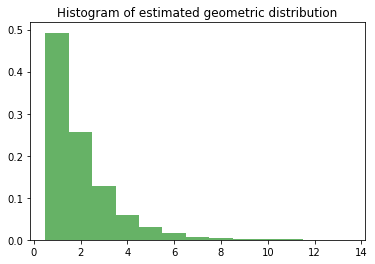

In [325]:
import random
import numpy as np
import matplotlib.pyplot as plt
U = []
N = 10000
p = 0.5
for _ in range(0, N-1):
    U.append(random.random())

X = []
for u in U:
    X.append(np.floor((np.log(u)/np.log(1-p))) + 1)

plt.hist(X, bins=np.arange(1, max(X)+1)-0.5, density=True, alpha=0.6, color='g')
plt.title("Histogram of estimated geometric distribution")
plt.show()

Chi-square (estimated vs Geometric(p=0.5))
Statistic = 4.6722, df = 6, p-value = 0.586489


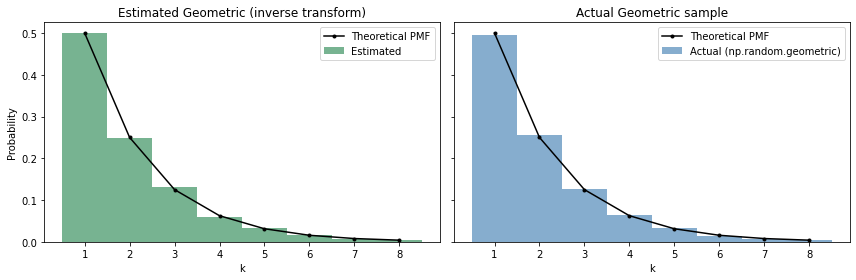

In [326]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, geom

# Setup
N = 10000
p = 0.5
rng = np.random.default_rng(42)

# Estimated sample via inverse transform
U = rng.random(N)
U = np.clip(U, 1e-12, 1 - 1e-12)  # avoid log(0)
X_est = (np.floor(np.log(U) / np.log(1 - p)) + 1).astype(int)

# "Actual" sample from built-in geometric generator
X_true = rng.geometric(p, size=N)

# ---- Chi-square GOF test for estimated sample vs theoretical Geometric(p) ----
# Use tail grouping so expected counts are not tiny
k_max = int(np.ceil(np.quantile(X_est, 0.99)))  # last bin is tail >= k_max
bins = np.arange(1, k_max)

obs_main = np.array([(X_est == k).sum() for k in bins], dtype=float)
obs_tail = (X_est >= k_max).sum()
obs = np.append(obs_main, obs_tail)

prob_main = geom.pmf(bins, p)
prob_tail = geom.sf(k_max - 1, p)  # P(X >= k_max)
probs = np.append(prob_main, prob_tail)

exp = N * probs

chi2_stat = np.sum((obs - exp) ** 2 / exp)
df = len(obs) - 1  # no parameter estimated from data
p_value = 1 - chi2.cdf(chi2_stat, df)

print(f"Chi-square (estimated vs Geometric(p={p}))")
print(f"Statistic = {chi2_stat:.4f}, df = {df}, p-value = {p_value:.6g}")

# ---- Side-by-side histograms ----
max_x = int(np.quantile(np.concatenate([X_est, X_true]), 0.995))
x_vals = np.arange(1, max_x + 1)
pmf_vals = geom.pmf(x_vals, p)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Estimated
ax[0].hist(X_est, bins=np.arange(1, max_x + 2) - 0.5, density=True, alpha=0.65, color='seagreen', label='Estimated')
ax[0].plot(x_vals, pmf_vals, 'ko-', ms=3, lw=1.5, label='Theoretical PMF')
ax[0].set_title("Estimated Geometric (inverse transform)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Probability")
ax[0].legend()

# Actual (numpy geometric)
ax[1].hist(X_true, bins=np.arange(1, max_x + 2) - 0.5, density=True, alpha=0.65, color='steelblue', label='Actual (np.random.geometric)')
ax[1].plot(x_vals, pmf_vals, 'ko-', ms=3, lw=1.5, label='Theoretical PMF')
ax[1].set_title("Actual Geometric sample")
ax[1].set_xlabel("k")
ax[1].legend()

plt.tight_layout()
plt.show()

### Part 2

In [327]:
X = [1,2,3,4,5,6]
p = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]

U = []
N = 10000
for _ in range(0, N-1):
    U.append(random.random())

# (a) direct (crude) method.
def crude_method(p, U, n):
    cum_p = np.cumsum([0] + list(p))
    X = []
    for u in U:
        for i in range(1, n+1):
            if cum_p[i-1] < u <= cum_p[i]:
                X.append(i)
                break
    return np.array(X)


X_crude = crude_method(p, U, len(p))

# (b) Rejection method
def rejection_method(p, U, n, c):
    X = []
    i = 0
    while i < len(U) - 1:
        u1 = U[i]
        i += 1
        I = int(np.floor(u1 * n))
        
        u2 = U[i]
        i += 1
        
        if u2 <= p[I] / c:
            X.append(I + 1)
    return np.array(X)

c = max(p) * len(p)
X_rejection = rejection_method(p, U, len(p), c)

# (c) Alias method
def alias_method(p, U, n, eps=1e-10):
    F = n * np.array(p)
    L = np.zeros(n, dtype=int)
    S = []
    G = []
    
    for i in range(n):
        if F[i] < 1 - eps:
            S.append(i)
        else:
            G.append(i)
    
    while len(S) > 0 and len(G) > 0:
        i = S.pop(0)
        j = G[0]
        
        L[i] = j 
        F[j] = F[j] - (1 - F[i])
        
        if F[j] < 1 - eps:
            G.pop(0)
            S.append(j)

    X = []
    i = 0
    while i < len(U) - 1:
        u1 = U[i]
        i += 1
        u2 = U[i]
        i += 1
        I = int(np.floor(u1 * n))
        
        if u2 <= F[I]:
            X.append(I + 1)
        else:
            X.append(L[I] + 1)
    
    return X

X_alias = alias_method(p, U, len(p))

### Part 3


Crude Method:
  Observed: [1414 1018 1303  645 2491 3128]
  Expected: [1458 1041 1249  624 2499 3124]
  Chi-square statistic: 4.8083
  Degrees of freedom: 5
  P-value: 0.4397
  Critical value (α=0.05): 11.0705
  PASS (fail to reject H0 at α=0.05)

Rejection Method:
  Observed: [ 64  51  60  25 105 136]
  Expected: [ 64  45  55  27 110 137]
  Chi-square statistic: 1.5026
  Degrees of freedom: 5
  P-value: 0.9128
  Critical value (α=0.05): 11.0705
  PASS (fail to reject H0 at α=0.05)

Alias Method:
  Observed: [ 689  512  675  303 1259 1561]
  Expected: [ 729  520  624  312 1249 1562]
  Chi-square statistic: 6.7186
  Degrees of freedom: 5
  P-value: 0.2424
  Critical value (α=0.05): 11.0705
  PASS (fail to reject H0 at α=0.05)


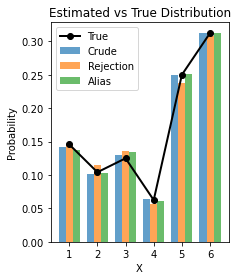


Sample sizes: Crude=9999, Rejection=441, Alias=4999


In [328]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import random

# Setup
X_vals = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
n = len(p)
N = 10000

np.random.seed(42)
U = np.random.random(N)

def chi_square_test(X, p, N, method_name):
    observed = np.bincount(X, minlength=n+1)[1:]
    expected = N * np.array(p)
    
    print(f"\n{method_name}:")
    print(f"  Observed: {observed}")
    print(f"  Expected: {expected.astype(int)}")
    
    chi2_stat = np.sum((observed - expected)**2 / expected)
    df = n - 1
    p_value = 1 - stats.chi2.cdf(chi2_stat, df)
    
    print(f"  Chi-square statistic: {chi2_stat:.4f}")
    print(f"  Degrees of freedom: {df}")
    print(f"  P-value: {p_value:.4f}")
    
    crit = stats.chi2.ppf(0.95, df)
    print(f"  Critical value (α=0.05): {crit:.4f}")
    print(f"  {'PASS' if chi2_stat < crit else 'FAIL'} (fail to reject H0 at α=0.05)")
    
    return chi2_stat, p_value

# Run tests
chi_square_test(X_crude, p, len(X_crude), "Crude Method")
chi_square_test(X_rejection, p, len(X_rejection), "Rejection Method")
chi_square_test(X_alias, p, len(X_alias), "Alias Method")

# --- Visualization ---
plt.subplot(1, 2, 2)
x = np.arange(1, n+1)
width = 0.25

# Normalize histograms to probabilities for comparison
def normalize_counts(X, n):
    counts = np.bincount(X, minlength=n+1)[1:]
    return counts / len(X)

plt.bar(x - width, normalize_counts(X_crude, n), width, label='Crude', alpha=0.7)
plt.bar(x, normalize_counts(X_rejection, n), width, label='Rejection', alpha=0.7)
plt.bar(x + width, normalize_counts(X_alias, n), width, label='Alias', alpha=0.7)
plt.plot(x, p, 'ko-', label='True', linewidth=2)
plt.title("Estimated vs True Distribution")
plt.xlabel("X")
plt.ylabel("Probability")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

# --- Sample sizes ---
print(f"\nSample sizes: Crude={len(X_crude)}, Rejection={len(X_rejection)}, Alias={len(X_alias)}")

# Exercise 3

### Part 1

KS test for Exponential: D=0.0074, p-value=0.6343


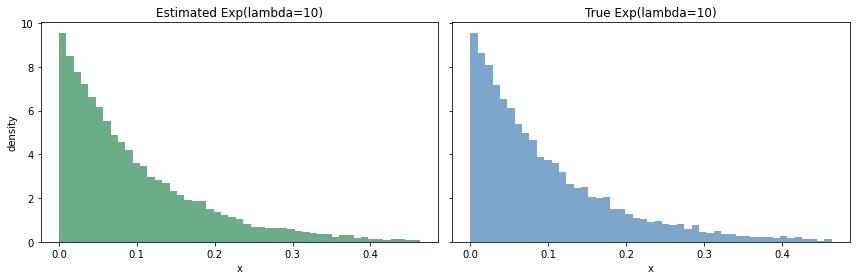

KS test for Standard Normal: D=0.0115, p-value=0.1423


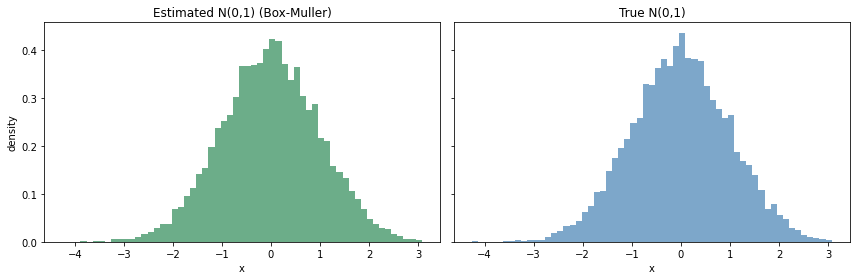

KS test for Pareto(k=2.05, beta=1): D=0.0050, p-value=0.9634


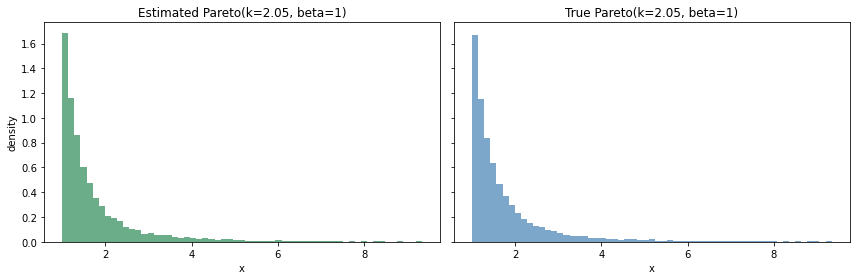

KS test for Pareto(k=2.5, beta=1): D=0.0079, p-value=0.5521


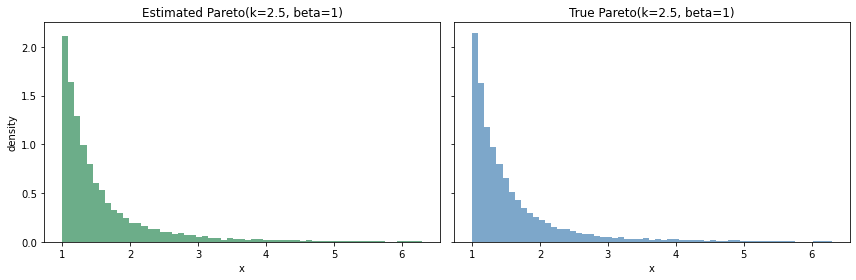

KS test for Pareto(k=3, beta=1): D=0.0090, p-value=0.3876


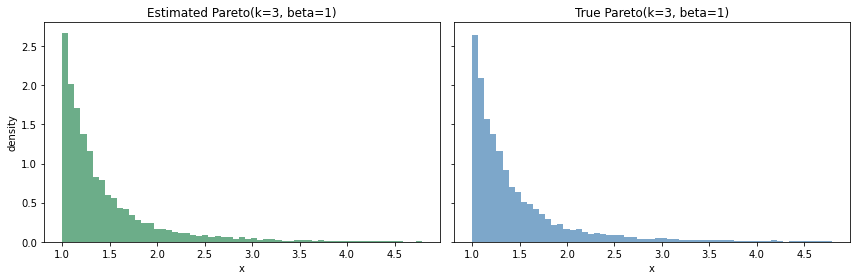

KS test for Pareto(k=4, beta=1): D=0.0073, p-value=0.6526


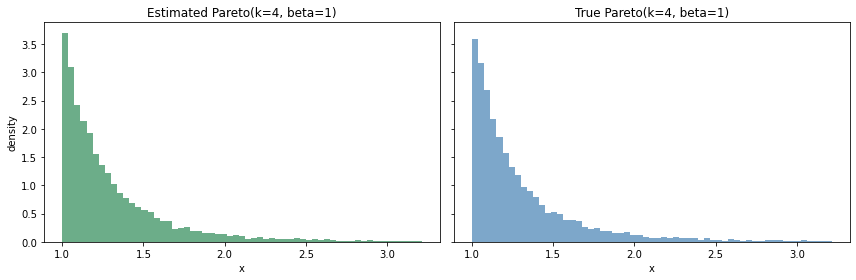

In [329]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

rng = np.random.default_rng(42)
N = 10000

def side_by_side_hist(x_est, x_true, title_est, title_true, bins=50, q=0.99):
    # Use common bins and trim at a high quantile to keep heavy tails readable
    xmax = np.quantile(np.concatenate([x_est, x_true]), q)
    xmin = min(np.min(x_est), np.min(x_true))
    common_bins = np.linspace(xmin, xmax, bins)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    ax[0].hist(x_est, bins=common_bins, density=True, alpha=0.7, color="seagreen")
    ax[0].set_title(title_est)
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("density")

    ax[1].hist(x_true, bins=common_bins, density=True, alpha=0.7, color="steelblue")
    ax[1].set_title(title_true)
    ax[1].set_xlabel("x")

    plt.tight_layout()
    plt.show()

# (a) Exponential: estimated vs true
lam = 10
U = rng.random(N)
X_est_exp = -np.log(U) / lam
X_true_exp = rng.exponential(scale=1/lam, size=N)
D, p_ks = kstest(X_est_exp, 'expon', args=(0, 1/lam))
print(f"KS test for Exponential: D={D:.4f}, p-value={p_ks:.4f}")
side_by_side_hist(
    X_est_exp,
    X_true_exp,
    "Estimated Exp(lambda=10)",
    "True Exp(lambda=10)"
)

# (b) Standard normal via Box-Muller: estimated vs true
U1 = rng.random(N // 2)
U2 = rng.random(N // 2)
R = np.sqrt(-2 * np.log(U1))
Theta = 2 * np.pi * U2
Z1 = R * np.cos(Theta)
Z2 = R * np.sin(Theta)
X_est_norm = np.concatenate([Z1, Z2])[:N]
X_true_norm = rng.normal(loc=0, scale=1, size=N)
D, p_ks = kstest(X_est_norm, 'norm', args=(0, 1))
print(f"KS test for Standard Normal: D={D:.4f}, p-value={p_ks:.4f}")    
side_by_side_hist(
    X_est_norm,
    X_true_norm,
    "Estimated N(0,1) (Box-Muller)",
    "True N(0,1)",
    bins=60,
    q=0.999
)

# (c) Pareto(beta=1, k): estimated vs true for each k
k_values = [2.05, 2.5, 3, 4]
beta = 1.0

for k in k_values:
    U = rng.random(N)

    # Type-I Pareto with beta=1 support x >= 1
    X_est_par = beta * (U ** (-1 / k))
    X_true_par = beta * (rng.pareto(k, N) + 1)

    D, p_ks = kstest(X_est_par, 'pareto', args=(k, 0, beta))
    print(f"KS test for Pareto(k={k}, beta=1): D={D:.4f}, p-value={p_ks:.4f}")

    side_by_side_hist(
        X_est_par,
        X_true_par,
        f"Estimated Pareto(k={k}, beta=1)",
        f"True Pareto(k={k}, beta=1)",
        bins=60,
        q=0.99
    )

### Part 2

In [330]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
N = 10000
beta = 1.0
k_values = [2.05, 2.5, 3, 4]

rows = []

for k in k_values:
    U = rng.random(N)
    X = beta * (U ** (-1 / k))

    sample_mean = np.mean(X)
    sample_var = np.var(X, ddof=1)

    theo_mean = beta * k / (k - 1) if k > 1 else np.inf
    theo_var = (beta**2) * k / (((k - 1)**2) * (k - 2)) if k > 2 else np.inf

    rows.append({
        "k": k,
        "sample_mean": sample_mean,
        "theoretical_mean": theo_mean,
        "sample_variance": sample_var,
        "theoretical_variance": theo_var
    })

df = pd.DataFrame(rows)

# Helpful relative errors (skip inf safely)
df["mean_rel_error_%"] = 100 * np.abs(df["sample_mean"] - df["theoretical_mean"]) / df["theoretical_mean"]
df["var_rel_error_%"] = 100 * np.abs(df["sample_variance"] - df["theoretical_variance"]) / df["theoretical_variance"]

print(df.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

     k  sample_mean  theoretical_mean  sample_variance  theoretical_variance  mean_rel_error_%  var_rel_error_%
2.0500       1.9409            1.9524           4.1515               37.1882            0.5862          88.8365
2.5000       1.6853            1.6667           3.2601                2.2222            1.1193          46.7048
3.0000       1.5042            1.5000           0.8013                0.7500            0.2808           6.8401
4.0000       1.3326            1.3333           0.2205                0.2222            0.0544           0.7580


### Part 3

In [331]:
import numpy as np
from scipy.stats import t, chi2

def box_muller_sample(n, rng):
    m = (n + 1) // 2
    u1 = rng.random(m)
    u2 = rng.random(m)

    r = np.sqrt(-2.0 * np.log(u1))
    theta = 2.0 * np.pi * u2

    z1 = r * np.cos(theta)
    z2 = r * np.sin(theta)

    z = np.empty(2 * m)
    z[0::2] = z1
    z[1::2] = z2
    return z[:n]

mu_true = 0.0
sigma_true = 1.0
var_true = sigma_true**2

m = 100
n = 10
alpha = 0.05

rng = np.random.default_rng(42)

mean_cover = []
var_cover = []
var_highs = []
var_lows = []
mean_lows = []
mean_highs = []

for _ in range(m):
    z = box_muller_sample(n, rng)
    x = mu_true + sigma_true * z

    xbar = np.mean(x)
    s2 = np.var(x, ddof=1)
    s = np.sqrt(s2)
    df = n - 1

    # 95% CI for mean
    tcrit = t.ppf(1 - alpha/2, df)
    mean_lo = xbar - tcrit * s / np.sqrt(n)
    mean_hi = xbar + tcrit * s / np.sqrt(n)

    # 95% CI for variance
    chi2_lo = chi2.ppf(alpha/2, df)
    chi2_hi = chi2.ppf(1 - alpha/2, df)
    var_lo = df * s2 / chi2_hi
    var_hi = df * s2 / chi2_lo

    mean_lows.append(mean_lo)
    mean_highs.append(mean_hi)
    var_lows.append(var_lo)
    var_highs.append(var_hi)
    mean_cover.append(mean_lo <= mu_true <= mean_hi)
    var_cover.append(var_lo <= var_true <= var_hi)

mean_cover = np.array(mean_cover)
var_cover = np.array(var_cover)

avg_mean_low = np.mean(mean_lows)
avg_mean_high = np.mean(mean_highs)
avg_var_low = np.mean(var_lows)
avg_var_high = np.mean(var_highs)

print(f"Average mean CI: [{avg_mean_low:.4f}, {avg_mean_high:.4f}]")
print(f"Average variance CI: [{avg_var_low:.4f}, {avg_var_high:.4f}]")

print(f"Mean CI coverage: {mean_cover.sum()}/{m} = {mean_cover.mean():.3f}")
print(f"Variance CI coverage: {var_cover.sum()}/{m} = {var_cover.mean():.3f}")

Average mean CI: [-0.7574, 0.6554]
Average variance CI: [0.4962, 3.4956]
Mean CI coverage: 93/100 = 0.930
Variance CI coverage: 93/100 = 0.930


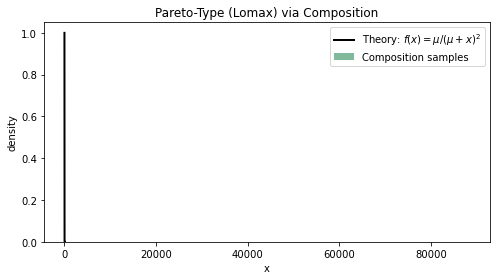

KS test: D=0.0037, p-value=0.1223


In [332]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

rng = np.random.default_rng(42)
N = 100000
mu = 1.0

Y = rng.exponential(scale=1/mu, size=N)

X_comp = rng.exponential(scale=1/Y)

x_grid = np.linspace(0, np.quantile(X_comp, 0.99), 400)
f_theory = mu / (mu + x_grid)**2

plt.figure(figsize=(7,4))
plt.hist(X_comp, bins=80, density=True, alpha=0.6, color="seagreen", label="Composition samples")
plt.plot(x_grid, f_theory, "k-", lw=2, label=r"Theory: $f(x)=\mu/(\mu+x)^2$")
plt.title("Pareto-Type (Lomax) via Composition")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()
D, p = kstest(X_comp, "lomax", args=(1, 0, mu))
print(f"KS test: D={D:.4f}, p-value={p:.4f}")

### Part 4

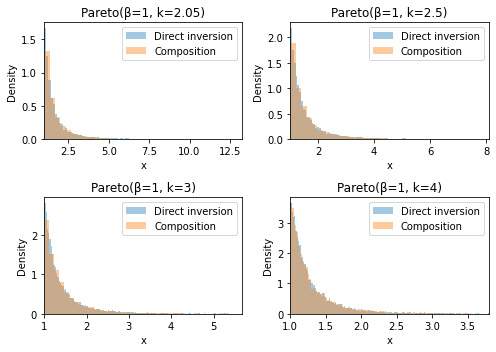


k = 2.05
Direct vs theoretical: statistic = 0.0065, p = 0.7880
Comp vs theoretical:   statistic = 0.0073, p = 0.6633
Direct vs comp:        statistic = 0.0115, p = 0.5229

k = 2.5
Direct vs theoretical: statistic = 0.0101, p = 0.2528
Comp vs theoretical:   statistic = 0.0107, p = 0.1974
Direct vs comp:        statistic = 0.0191, p = 0.0521

k = 3
Direct vs theoretical: statistic = 0.0109, p = 0.1835
Comp vs theoretical:   statistic = 0.0081, p = 0.5261
Direct vs comp:        statistic = 0.0178, p = 0.0841

k = 4
Direct vs theoretical: statistic = 0.0077, p = 0.5906
Comp vs theoretical:   statistic = 0.0104, p = 0.2318
Direct vs comp:        statistic = 0.0096, p = 0.7462


In [333]:
# Exercise 3 - Part 4

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(33)

N = 10000
beta = 1
k_values = [2.05, 2.5, 3, 4]

X_direct = np.zeros((len(k_values), N))

# Direct inversion method for all k values
for i, k in enumerate(k_values):
    U = np.random.uniform(0, 1, size=N)
    X_direct[i, :] = beta * (U ** (-1 / k)) 


# Composition method for all k values

# Step 1: generate exponential with rate k
X_comp = np.zeros((len(k_values), N))

for i, k in enumerate(k_values):
    U_exp = np.random.uniform(0, 1, size=N)
    Y = -np.log(U_exp) / k           

# Step 2: transform exponential to Pareto
    X_comp[i, :] = beta * np.exp(Y)         



fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten() 

for idx, k in enumerate(k_values):
    x_grid = np.linspace(beta, np.percentile(X_direct[idx, :], 99.5), 500)
    pdf_pareto = k * beta**k / x_grid**(k + 1)
    ax = axes[idx]
    ax.hist(X_direct[idx, :], bins=500, density=True, alpha=0.4, label="Direct inversion")
    ax.hist(X_comp[idx, :], bins=500, density=True, alpha=0.4, label="Composition")
    #ax.plot(x_grid, pdf_pareto, 'k', linewidth=2, label="Theoretical PDF")
    ax.set_xlim(beta, np.percentile(X_direct[idx, :], 99.5))
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.set_title(f"Pareto(β={beta}, k={k})")
    ax.legend()
    
plt.tight_layout()
#plt.savefig("pareto_comparison.png", dpi=300)
plt.show()

for idx, k in enumerate(k_values):
    ks_direct = stats.kstest(X_direct[idx, :], 'pareto', args=(k, 0, beta))
    ks_comp   = stats.kstest(X_comp[idx, :], 'pareto', args=(k, 0, beta))
    ks_between = stats.ks_2samp(X_direct[idx, :], X_comp[idx, :])

    print(f"\nk = {k}")
    print(f"Direct vs theoretical: statistic = {ks_direct.statistic:.4f}, p = {ks_direct.pvalue:.4f}")
    print(f"Comp vs theoretical:   statistic = {ks_comp.statistic:.4f}, p = {ks_comp.pvalue:.4f}")
    print(f"Direct vs comp:        statistic = {ks_between.statistic:.4f}, p = {ks_between.pvalue:.4f}")


# Exercise 4

### Part 1

In [334]:
import scipy.stats as stats
import numpy as np
m = 10
mst = 8
mtvc = 1

n = 10000
block_fractions = []
for i in range(0,m):
    blocked = 0
    # Simulate 10000 arrivals using 8 Erlang distribution
    arrivals = stats.poisson.rvs(mu=mst, size=n)
    for arrival in arrivals:
        # Generate next time interval from Exp(mtsv, 1)
        next_interval = stats.expon.rvs(scale=mtvc, size=1)
        # remove all completed services (depatures before arrival time)
        arrivals = arrivals[next_interval > arrivals]
        # If fewer than m in service, accept customer, generate service time from Exp(mean, 8), store departure time
        if len(arrivals) < m:
            service_time = stats.expon.rvs(scale=mst*mtvc, size=1)
            departure_time = next_interval + service_time
            # Store departure time for next iteration
        else:
            blocked += 1
    block_fractions.append(blocked / n)
print(block_fractions)
print("Mean Blocking Fraction:", np.mean(block_fractions))
print(f"Confidence Interval: {np.mean(block_fractions)} ± {1.96 * np.std(block_fractions) / np.sqrt(len(block_fractions))}")


[0.0, 0.0, 0.0, 0.0002, 0.0, 0.0, 0.0001, 0.0003, 0.0, 0.0]
Mean Blocking Fraction: 5.9999999999999995e-05
Confidence Interval: 5.9999999999999995e-05 ± 6.320810074666063e-05


In [335]:
import numpy as np
import heapq
from scipy.stats import t as student_t

# Parameters from the exercise
m = 10                      # number of servers
mean_service_time = 8.0     # E[S]
mean_interarrival = 1.0     # E[A]
n_customers = 10_000        # per replication
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []

for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []  # min-heap of service completion times for customers in service

    for _ in range(n_customers):
        # Poisson arrivals <=> exponential interarrival times
        t_now += rng.exponential(scale=mean_interarrival)

        # Remove all customers that have completed service before this arrival
        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        # If a server is free, accept; otherwise block
        if len(departures) < m:
            service_time = rng.exponential(scale=mean_service_time)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

# 95% CI across replications (t-interval)
mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

# Erlang-B theoretical blocking probability for M/M/m/m
lam = 1.0 / mean_interarrival
A = lam * mean_service_time  # offered traffic in Erlang

B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.1217, 0.1182, 0.1186, 0.1271, 0.1253, 0.1232, 0.131, 0.1196, 0.118, 0.1186]
Mean blocking fraction: 0.122130
95% CI: [0.118943, 0.125317]
Erlang-B theoretical blocking: 0.121661


### Part 2

In [336]:
import numpy as np
import heapq
from scipy.stats import t as student_t
import scipy.stats as stats

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []

for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        t_now += rng.exponential(scale=mean_interarrival)

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            service_time = stats.erlang.rvs(a=mean_service_time, scale=1.0, random_state=rng)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time

B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.1206, 0.1184, 0.1177, 0.1238, 0.1262, 0.1283, 0.124, 0.1232, 0.1277, 0.128]
Mean blocking fraction: 0.123790
95% CI: [0.121011, 0.126569]
Erlang-B theoretical blocking: 0.121661


In [337]:
import numpy as np
import heapq
from scipy.stats import t as student_t
import scipy.stats as stats

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []

lambda1 = 0.8333
lambda2 = 5.0
p1 = 0.8

for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        if rng.random() < p1:
            interarrival = rng.exponential(scale=1 / lambda1)
        else:
            interarrival = rng.exponential(scale=1 / lambda2)
        t_now += interarrival

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            service_time = rng.exponential(scale=mean_service_time)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time

B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.1345, 0.1343, 0.1446, 0.1348, 0.1395, 0.1262, 0.1285, 0.1313, 0.1513, 0.1308]
Mean blocking fraction: 0.135580
95% CI: [0.130108, 0.141052]
Erlang-B theoretical blocking: 0.121661


### Part 3

##### (a)

In [338]:
import numpy as np
import heapq
from scipy.stats import t as student_t

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []
for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        t_now += rng.exponential(scale=mean_interarrival)

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            service_time = mean_service_time
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time
B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.1285, 0.1198, 0.1208, 0.1211, 0.1223, 0.1194, 0.1228, 0.119, 0.1278, 0.1171]
Mean blocking fraction: 0.121860
95% CI: [0.119212, 0.124508]
Erlang-B theoretical blocking: 0.121661


##### (b)

In [339]:
import numpy as np
import heapq
from scipy.stats import t as student_t

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []
k = 2.05
for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        t_now += rng.exponential(scale=mean_interarrival)

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            # Pareto distribution with shape k and scale 1
            service_time = (rng.pareto(a=k) + 1) * (mean_service_time / (k / (k - 1)))
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time
B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.1225, 0.125, 0.1193, 0.1282, 0.1147, 0.1169, 0.1204, 0.1157, 0.1192, 0.1325]
Mean blocking fraction: 0.121440
95% CI: [0.117369, 0.125511]
Erlang-B theoretical blocking: 0.121661


##### (c)

In [340]:
import numpy as np
import heapq
from scipy.stats import t as student_t

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []
k = 2.05
for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        t_now += rng.exponential(scale=mean_interarrival)

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            # Normal distribution
            service_time = rng.normal(loc=mean_service_time, scale=mean_service_time / 2)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time
B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.1253, 0.1235, 0.1149, 0.1137, 0.1143, 0.1167, 0.1239, 0.1271, 0.1237, 0.1365]
Mean blocking fraction: 0.121960
95% CI: [0.116832, 0.127088]
Erlang-B theoretical blocking: 0.121661


# Exercise 5

### Part 1

In [341]:
import numpy as np
from random import random

# Set seed
np.random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random())

U = np.array(U)
X = np.exp(U)

mean_X = np.mean(X)
print("Mean of X:", mean_X)

# Estimate confidence intervals
s2 = np.var(X, ddof=1)
alpha = 0.05
lower_bound = mean_X - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_X + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of X: [{lower_bound}, {upper_bound}]")

# Theoretical mean of X
theoretical_mean_X = np.exp(1) - 1
print("Theoretical mean of X:", theoretical_mean_X)

Mean of X: 1.7188885450129507
95% confidence interval for the mean of X: [1.625259350427487, 1.8125177395984144]
Theoretical mean of X: 1.718281828459045


### Part 2

In [342]:
import numpy as np
from random import random

# Set seed
np.random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random())

U = np.array(U)
Y = (np.exp(U) + np.exp(1-U)) / 2

mean_Y = np.mean(Y)
print("Mean of Y:", mean_Y)

# Estimate confidence intervals
s2 = np.var(Y, ddof=1)
alpha = 0.05
lower_bound = mean_Y - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_Y + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of Y: [{lower_bound}, {upper_bound}]")

# Theoretical mean of Y
theoretical_mean_Y = np.exp(1) - 1
print("Theoretical mean of Y:", theoretical_mean_Y)

Mean of Y: 1.7198170360540472
95% confidence interval for the mean of Y: [1.7079231521867362, 1.7317109199213583]
Theoretical mean of Y: 1.718281828459045


### Part 3

In [343]:
import numpy as np
import random

# Set seed
np.random.seed(0)
random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random.random())

U = np.array(U)
X = np.exp(U)
Y = U
mean_Y = 0.5
c = -np.cov(X, Y)[0, 1] / np.var(Y)
Z = X + c * (Y - mean_Y)

mean_Z = np.mean(Z)
print("Mean of Z:", mean_Z)

# Estimate confidence intervals
s2 = np.var(Z, ddof=1)
alpha = 0.05
lower_bound = mean_Z - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_Z + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of Z: [{lower_bound}, {upper_bound}]")

# Theoretical mean of Z
theoretical_mean_Z = np.exp(1) - 1
print("Theoretical mean of Z:", theoretical_mean_Z)

Mean of Z: 1.7055199178231613
95% confidence interval for the mean of Z: [1.6936509820046652, 1.7173888536416573]
Theoretical mean of Z: 1.718281828459045


### Part 4

In [344]:
import numpy as np
import random

# Set seed
np.random.seed(0)
random.seed(0)

strata = 10

U = []
n = 100
for i in range(n):
    U.append(random.random())

U = np.array(U)
W = 0
for i in range(strata):   # 0..9
    W += np.exp(i/strata + U[i::strata])
W = W / strata

mean_X = np.mean(W)
print("Mean of X:", mean_X)

# Estimate confidence intervals
s2 = np.var(W, ddof=1)
alpha = 0.05
lower_bound = mean_X - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_X + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of X: [{lower_bound}, {upper_bound}]")

# Theoretical mean of X
theoretical_mean_X = np.exp(1) - 1
print("Theoretical mean of X:", theoretical_mean_X)

Mean of X: 3.0605892281628053
95% confidence interval for the mean of X: [3.0143960989696623, 3.1067823573559483]
Theoretical mean of X: 1.718281828459045


### Part 5

In [345]:
import numpy as np
import heapq
from scipy.stats import t as student_t

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []

Xr = []
Cr = []
for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        t_now += rng.exponential(scale=mean_interarrival)

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            service_time = rng.exponential(scale=mean_service_time)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1
    Xr.append(blocked / n_customers)
    Cr.append(t_now)

c = -np.cov(Xr, Cr)[0, 1] / np.var(Cr)
Zr = np.array(Xr) + c * (np.array(Cr) - np.mean(Cr))

block_fractions = Zr

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time

B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Mean blocking fraction: 0.122130
95% CI: [0.119086, 0.125174]
Erlang-B theoretical blocking: 0.121661


In [346]:
print(0.118943- 0.125317)
print(0.119086- 0.125174)

-0.0063740000000000185
-0.00608800000000001


### Part 7

In [347]:
import numpy as np
import scipy.stats as stats
# Set seed
np.random.seed(0)
N = 10000
a = 2
Z = np.random.normal(loc=0, scale=1, size=N)
X = Z > a

prop = np.mean(X)
print(f"Estimated P(X > {a}):", prop)
print(f"Theoretical P(X > {a}):", 1 - stats.norm.cdf(a))

N = 10000
a = 4
Z = np.random.normal(loc=0, scale=1, size=N)
X = Z > a

prop = np.mean(X)
print(f"Estimated P(X > {a}):", prop)
print(f"Theoretical P(X > {a}):", 1 - stats.norm.cdf(a))

Estimated P(X > 2): 0.0212
Theoretical P(X > 2): 0.02275013194817921
Estimated P(X > 4): 0.0
Theoretical P(X > 4): 3.167124183311998e-05


In [348]:
import numpy as np
from scipy import stats

N = 10000
a = 2

Z = np.random.normal(loc=a, scale=1, size=N)

X = Z > a

W = np.exp(-a * Z + 0.5 * a**2)

prop = np.mean(X * W)

print(f"Estimated P(X > {a}):", prop)
print(f"Theoretical P(X > {a}):", 1 - stats.norm.cdf(a))

N = 10000
a = 4

Z = np.random.normal(loc=a, scale=1, size=N)

X = Z > a

W = np.exp(-a * Z + 0.5 * a**2)

prop = np.mean(X * W)

print(f"Estimated P(X > {a}):", prop)
print(f"Theoretical P(X > {a}):", 1 - stats.norm.cdf(a))

Estimated P(X > 2): 0.022902129216389084
Theoretical P(X > 2): 0.02275013194817921
Estimated P(X > 4): 3.289513722001599e-05
Theoretical P(X > 4): 3.167124183311998e-05


### Part 8

In [349]:
import numpy as np
n = 10000
def Var(lambda_):
    var = (np.exp(lambda_+2) - 1)/(lambda_*(lambda_+2)) - (np.exp(1) - 1)**2
    return var

values = np.linspace(0, 10, n)

outputs = Var(values)
optimal_lambda = values[np.argmin(outputs)]
print("Optimal lambda:", optimal_lambda)

Optimal lambda: 1.3551355135513552


<ipython-input-349-a4ed4f67123f>:4: RuntimeWarning: divide by zero encountered in true_divide
  var = (np.exp(lambda_+2) - 1)/(lambda_*(lambda_+2)) - (np.exp(1) - 1)**2


In [350]:
n = 100000
Z = np.random.exponential(scale=1/optimal_lambda, size=n)
I = Z <= 1
theta = (1/optimal_lambda)*np.exp((optimal_lambda+1)*np.array(Z))*I

true_integral = np.exp(1) - 1
print("True integral:", true_integral)
print("Integral:", np.mean(theta))

True integral: 1.718281828459045
Integral: 1.7171775776125882


### Part 9

In [351]:
# Parameters
xm = 1.0
alpha = 3.0
n = 10000

# Sample from g(x) = Pareto(xm, alpha-1)
U = np.random.uniform(0, 1, n)
X = xm * (1 - U) ** (-1 / (alpha - 1))

# Target density f(x)
def f(x):
    return alpha * xm**alpha / x**(alpha + 1)

# Proposal density g(x)
def g(x):
    return (alpha - 1) * xm**(alpha - 1) / x**alpha

# Importance sampling estimator
weights = f(X) / g(X)

theta_hat = np.mean(X * weights)

print("IS estimate (Pareto mean):", theta_hat)
print("True mean:", alpha * xm / (alpha - 1))

IS estimate (Pareto mean): 1.5
True mean: 1.5


# Exercise 6

### Part 1

In [352]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import time

In [353]:
#Define theoretical pmf
def truncated_poisson_pmf(i, m, A):
    #normalisation of dist
    norm = 0
    for k in range(0,m+1):
        norm += A**k / math.factorial(k)
        
    numerator = A**i / math.factorial(i)
    return numerator/norm

In [354]:
#Define g(x) function from f(x)=c*g(x)
def g_density(x, A):
    return A**x / math.factorial(x)

#Define proposal function
def h_proposal(m):
    return sp.stats.randint.rvs(low=0,high=m+1)

In [355]:
### Metropolis-Hastings algorithm for Erlang system (system following truncating Poisson distribution)
def MH_Erlang_sys(n_sample, m, A):
    #Convert to int
    n_sample = int(n_sample)

    ## Step 0)
    #Initialise list for samples
    X = []
    #Initialise state x from proposal functionh(x,y)
    x = h_proposal(m)
    X.append(x)

    #Acceptance counter
    accept_count = 0
    #start timing
    start1 = time.time()

    ## Start loop
    for _ in range(n_sample-1):
        ## Step 1)
        #Start from current state
        x = X[-1]
        #Propose candidate state
        y = h_proposal(m)

        ## Step 2)
        #Compute acceptance probability to go from x -> y
        alpha = min(1, g_density(y, A)/g_density(x,A))

        ## Step 3)
        #If accepted, move to y
        if sp.stats.uniform.rvs() <= alpha:
            X.append(y)
            #Count acceptance
            accept_count += 1
        ## Step 4)
        #Otherwise, remain at x (append x again)
        else:
            X.append(x)
 
    #end timing
    end1 = time.time()
    runtime1 = end1-start1
    return np.array(X), accept_count, runtime1

In [356]:
#Run simlation
m = 10
#A (offered traffic) from s (service time mean)*lambda (arrival time rate)
A = 8
n_sample = 1e5

X, accept_count, runtime1 = MH_Erlang_sys(n_sample, m, A)

In [357]:
print("Size", len(X))
print("min val: ",min(X), " max val: ", max(X))
print(f"Acceptance rate: {accept_count/n_sample:.3f}")
print(f"runtime: {runtime1:.2f} s")

Size 100000
min val:  0  max val:  10
Acceptance rate: 0.594
runtime: 5.70 s


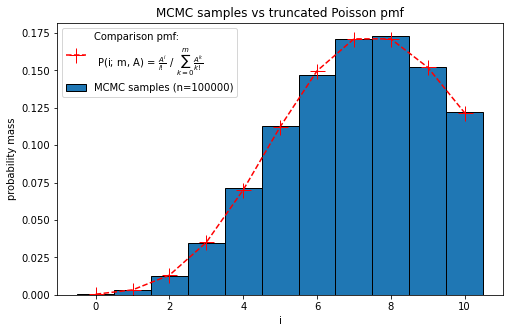

In [358]:
#Plot results
fig, ax = plt.subplots(figsize=(8,5))

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Histogram
ax.hist(
    X, 
    bins=edges,
    density=True,
    edgecolor='black',
    label= f"MCMC samples (n={n_sample:.0f})"
)

xgrid = np.arange(0,m+1)

#Evaluate pmf
pmf_vals = np.array([
    truncated_poisson_pmf(i, m, A)
    for i in range(0,m+1) 
])

plt.plot(
    xgrid,
    pmf_vals,
    label = ('Comparison pmf:\n'
             r' P(i; m, A) = $\frac{A^i}{i!} \ / \ \sum_{k=0}^{m} \frac{A^k}{k!}$'),
    color='red', 
    marker='+', 
    markersize=15, 
    linestyle='--'
)

ax.set_xlabel('i')
ax.set_ylabel('probability mass')
ax.set_title('MCMC samples vs truncated Poisson pmf')
ax.legend()
plt.show()

In [359]:
### Function for chi2 p_val
def chi2_GOF(obs, exp, df):
    chi2_stat = np.sum( (obs-exp)**2 / exp )
    p_val = 1 - sp.stats.chi2.cdf(chi2_stat, df=df)
    return chi2_stat, p_val

### Function for grouping such that expected bins are always above 5
def group_bins(obs, exp, threshold=5):
    obs = np.asarray(obs)
    exp = np.asarray(exp)

    grouped_obs = []
    grouped_exp = []

    o_sum = 0
    e_sum = 0

    for o, e in zip(obs, exp):
        o_sum += o
        e_sum += e

        # close group when expected count is large enough
        if e_sum >= threshold:
            grouped_obs.append(o_sum)
            grouped_exp.append(e_sum)
            o_sum = 0
            e_sum = 0

    # handle leftover tail (important!)
    if e_sum > 0:
        grouped_obs[-1] += o_sum
        grouped_exp[-1] += e_sum

    return np.array(grouped_obs), np.array(grouped_exp)

In [360]:
### Chi2 Goodness-of-fit test: creating observed and expected bins
#Observed bins (number of bins: m+1)
obs = np.bincount(X, minlength=m+1)

#Expedted vals (using pmf)
exp = len(X)*pmf_vals

#Checking:
print("Before regrouping bins")
print(f"Sum of obs: {sum(obs)}")
print(f"sum of exp: {sum(exp)}")
print("Observed values:")
print(obs)
print("Expected values:")
print(exp)
print("Is any expected val below 5? (if empty, then no):")
print(exp[exp<5])

### Apply grouping function
obs_g, exp_g = group_bins(obs=obs, exp=exp, threshold=5)

#Checking:
print("After regrouping bins")
print(f"Sum of obs_g: {sum(obs_g)}")
print(f"sum of exp_g: {sum(exp_g)}")
print("Expected values after grouping:")
print(exp_g)
print("Is any expected val below 5? (if empty, then no):")
print(exp_g[exp_g<5])

Before regrouping bins
Sum of obs: 100000
sum of exp: 99999.99999999999
Observed values:
[   41   338  1232  3450  7151 11260 14673 17074 17304 15225 12252]
Expected values:
[   41.11637082   328.93096653  1315.72386611  3508.59697629
  7017.19395258 11227.51032412 14970.0137655  17108.58716057
 17108.58716057 15207.63303162 12166.1064253 ]
Is any expected val below 5? (if empty, then no):
[]
After regrouping bins
Sum of obs_g: 100000
sum of exp_g: 99999.99999999999
Expected values after grouping:
[   41.11637082   328.93096653  1315.72386611  3508.59697629
  7017.19395258 11227.51032412 14970.0137655  17108.58716057
 17108.58716057 15207.63303162 12166.1064253 ]
Is any expected val below 5? (if empty, then no):
[]


In [361]:
### Chi2 Goodness-of-fit test: perfomrning test
df = len(exp_g) - 1
print(f"number of df: {df}")
chi2_stat, p_val = chi2_GOF(obs=obs_g, exp=exp_g, df=df)

print("chi2 test statistic:")
print(chi2_stat)
print("p_val:")
print(p_val)

number of df: 10
chi2 test statistic:
18.023184250635992
p_val:
0.05457381320379984


### Part 2

##### (a)

In [362]:
#Define theoretical pmf
def truncated_poisson_joint_pmf(i, j, m, A_1, A_2):
    #normalisation of dist
    norm = 0
    for k in range(0,m+1):
        for l in range(0, m+1-k):
            norm += (A_1**k / math.factorial(k))*(A_2**l / math.factorial(l))
        
    numerator = (A_1**i / math.factorial(i))*(A_2**j / math.factorial(j))
    return numerator/norm

In [363]:
#Define g(x) function from f(x)=c*g(x)
def g_density_joint(i, j, A_1, A_2):
    fac1 = A_1**i / math.factorial(i)
    fac2 = A_2**j / math.factorial(j)
    return fac1*fac2

#Define function for combinations
def combinations_joint(m):
    # Make a list of all possible (i,j) combinations, when 0 <= i+j <= m
    # Number of combinations (discrete 2D simplex):  (m+1)*(m+2)/2 
    pairs = []
    for i in range(m+1):
        for j in range(m+1-i):
            pairs.append((i,j))
    return pairs

#Define proposal function
def h_proposal_joint(pairs):
    """
    input:
        comb (list):    list of tuples of (i,j) combinations
    """
    #Draw random idx to choose between pairs (from uniform dist)
    ran_idx = sp.stats.randint.rvs(low=0,high=len(pairs))
    i_val = pairs[ran_idx][0]
    j_val = pairs[ran_idx][1]
    return [i_val, j_val]

In [364]:
### Metropolis-Hastings algorithm for joint Erlang system (system following truncating Poisson distribution)
def MH_joint_erlang_sys(n_sample, m, A_1, A_2):
    #Convert to int
    n_sample = int(n_sample)

    #Initialise list of combinations of (i,j) given m-values
    pairs = combinations_joint(m)

    ## Step 0)
    #Initialise list for samples
    X = []
    #Initialise state x=(i,j) from proposal function, h(x,y)
    x = h_proposal_joint(pairs)
    X.append(x)

    #Acceptance counter
    accept_count = 0

    #start timing
    start1 = time.time()
    ## Start loop
    for _ in range(n_sample - 1):
        ## Step 1)
        #Start from current state
        x = X[-1]
        #Propose candidate state
        y = h_proposal_joint(pairs)

        ## Step 2)
        #Compute acceptance probability to go from x -> y
        g_y = g_density_joint(y[0], y[1], A_1=A_1, A_2=A_2)
        g_x = g_density_joint(x[0], x[1], A_1=A_1, A_2=A_2)
        alpha = min(1, g_y / g_x)

        #Decide by RNG whether proposal is accepted or rejected
        ## Step 3)
        #If accepted, move to y
        if sp.stats.uniform.rvs() <= alpha:
            X.append(y)
            #Count acceptance
            accept_count += 1
        ## Step 4)
        #Otherwise, remain at x (append x again)
        else:
            X.append(x)

    #end timing
    end1 = time.time()
    runtime1 = end1-start1
    
    return np.array(X), accept_count, runtime1

In [365]:
### Set params
n_sample = 1e5
m = 10
#A (offered traffic). Value from ex.
A_1 = 4
A_2 = 4

### Run simlation
X_joint, acc_joint, runtime_joint = MH_joint_erlang_sys(n_sample=n_sample, m=m, A_1=A_1, A_2=A_2)

In [366]:
#Check values
print("Sahpe of samples", np.shape(X_joint))
print("min val: ",min(X), " max val: ", max(X))
print(f"Acceptance rate: {acc_joint/n_sample:.3f}")
print(f"runtime: {runtime_joint:.2f} s")

Sahpe of samples (100000, 2)
min val:  0  max val:  10
Acceptance rate: 0.480
runtime: 6.09 s


In [367]:
# Compute theoretical distribution on grid
P = np.zeros((m+1, m+1))
for i in range(m+1):
    for j in range(m+1-i):
        P[i,j] = truncated_poisson_joint_pmf(i, j, m, A_1, A_2)

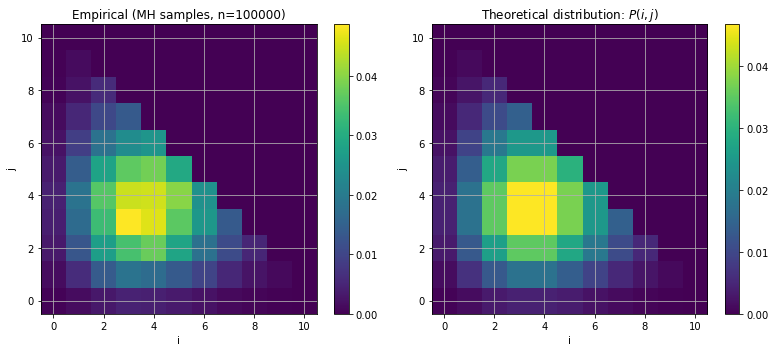

In [368]:
### PLotting joint dstribution
i_vals = X_joint[:,0]
j_vals = X_joint[:,1]

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Initialise fig, ax
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# Compute 2D histogram
Histogram, _, _ = np.histogram2d(i_vals, j_vals, bins=edges, density=True)

### Plot emperical heatmap
im0 = ax[0].imshow(
    Histogram.T, 
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[0].set_title(f"Empirical (MH samples, n={n_sample:.0f})")
ax[0].set_xlabel("i")
ax[0].set_ylabel("j")
ax[0].grid()
fig.colorbar(im0, ax=ax[0])

### Plot theoretical heatmap
im1 = ax[1].imshow(
    P.T,
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[1].set_title(r"Theoretical distribution: $P(i,j)$")
ax[1].set_xlabel("i")
ax[1].set_ylabel("j")
ax[1].grid()
fig.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

In [369]:
#Define theoretical marginal pmf from joint pmf

def truncated_poisson_marginal_pmf(i, m, A_1, A_2):
    sum = 0
    for j in range(m+1-i):
        sum += truncated_poisson_joint_pmf(i=i, j=j, m=m, A_1=A_1, A_2=A_2)
    return sum

#Evaluate marginal pmf
xgrid = np.arange(0,m+1)
marg_pmf_vals = np.array([
    truncated_poisson_marginal_pmf(i, m, A_1, A_2)
    for i in range(0,m+1) 
])

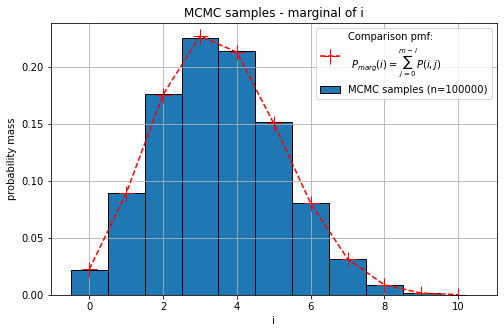

In [370]:
### PLotting marginal distribution

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Plot results
fig, ax = plt.subplots(figsize=(8,5))
#Histogram
ax.grid()
ax.hist(
    i_vals, 
    bins=edges,
    density=True,
    edgecolor='black',
    label= f"MCMC samples (n={n_sample:.0f})"
)
plt.plot(
    xgrid,
    marg_pmf_vals,
    label = ('Comparison pmf:\n'
             r' $P_{marg}(i) = \sum_{j=0}^{m-i} P(i,j)$'),
    color='red', 
    marker='+', 
    markersize=15, 
    linestyle='--'
)

ax.set_xlabel('i')
ax.set_ylabel('probability mass')
ax.set_title('MCMC samples - marginal of i')
ax.legend()
plt.show()

In [371]:
### Chi2 Goodness-of-fit test: creating observed and expected bins
#Observed bins (number of bins: m+1)
obs = np.bincount(i_vals, minlength=m+1)

#Expedted vals (using pmf)
exp = len(i_vals)*marg_pmf_vals

#Checking:
print("Before regrouping bins")
print(f"Sum of obs: {sum(obs)}")
print(f"sum of exp: {sum(exp)}")
print("Observed values:")
print(obs)
print("Expected values:")
print(exp)
print("Is any expected val below 5? (if empty, then no):")
print(exp[exp<5])

### Apply grouping function
obs_g, exp_g = group_bins(obs=obs, exp=exp, threshold=5)

#Checking:
print("After regrouping bins")
print(f"Sum of obs_g: {sum(obs_g)}")
print(f"sum of exp_g: {sum(exp_g)}")
print("Expected values after grouping:")
print(exp_g)
print("Is any expected val below 5? (if empty, then no):")
print(exp_g[exp_g<5])

Before regrouping bins
Sum of obs: 100000
sum of exp: 99999.99999999999
Observed values:
[ 2195  8895 17632 22519 21401 15143  8078  3131   836   154    16]
Expected values:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]
After regrouping bins
Sum of obs_g: 100000
sum of exp_g: 99999.99999999999
Expected values after grouping:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]


In [372]:
### Chi2 Goodness-of-fit test: performning test
df = len(exp_g) - 1
print(f"number of df: {df}")
chi2_stat, p_val = chi2_GOF(obs=obs_g, exp=exp_g, df=df)

print("chi2 test statistic:")
print(chi2_stat)
print("p_val:")
print(p_val)

number of df: 10
chi2 test statistic:
7.542218749754904
p_val:
0.6734542626576125


##### (b)

In [373]:
### Metropolis-Hastings algorithm for Erlang system - Coordinate-wise MH sampling
# Change: proposal now happens in each direction seperately, i.e. proposal function from 1D case used
# but i+j=m constrain enforced always
# Acceptance prob. still calculated from joint distribution

def MH_joint_erlang_sys_coord(n_sample, m, A_1, A_2):
    #Convert to int
    n_sample = int(n_sample)

    #Initialise list of combinations of (i,j) given m-values
    pairs = combinations_joint(m)

    ## Step 0)
    #Initialise list for samples
    X = []
    #Initialise state x=(i,j) from proposal function, h(x,y)
    x = h_proposal_joint(pairs)
    X.append(x)

    #Acceptance counter
    accept_count = 0
    #Start timing
    start1 = time.time()

    ## Start loop
    for _ in range(n_sample - 1):
        
        #Start from current state
        x = X[-1]

        ## Step 1)
        ## ---i coordinate---
        #Propose i-coord of candidate state (nb: i = m-j)
        i_prop = h_proposal(m-x[1])
        y = [i_prop, x[1]]

        ## Step 2)
        #Compute acceptance probability to go from x -> y
        g_y = g_density_joint(y[0], y[1], A_1=A_1, A_2=A_2)
        g_x = g_density_joint(x[0], x[1], A_1=A_1, A_2=A_2)
        alpha = min(1, g_y / g_x)

        ## Step 3)
        #If accepted, change i-coord
        if sp.stats.uniform.rvs() <= alpha:
            x = y
            #Count acceptance
            accept_count += 1
        ## Step 4)
        #Otherwise, don't change i-coord
        
        ## Step 1)
        ## ---j coordinate---
        #Propose j-coord of candidate state (nb: j=m-i)
        j_prop = h_proposal(m-x[0])
        y = [x[0], j_prop]

        ## Step 2)
        #Compute acceptance probability to go from x -> y
        g_y = g_density_joint(y[0], y[1], A_1=A_1, A_2=A_2)
        g_x = g_density_joint(x[0], x[1], A_1=A_1, A_2=A_2)
        alpha = min(1, g_y / g_x)

        ## Step 3)
        #If accepted, change j-coord
        if sp.stats.uniform.rvs() <= alpha:
            x = y
            #Count acceptance
            accept_count += 1
        ## Step 4)
        #Otherwise, don't change j-coord

        ## Save state after both update attempts
        X.append(x)
    
    #end timing
    end1 = time.time()
    runtime1 = end1-start1
    
    return np.array(X), accept_count, runtime1

In [374]:
### Set params
n_sample = 1e5
m = 10
#A (offered traffic). Value from ex.
A_1 = 4
A_2 = 4

### Run simlation
X_joint_coord, acc_joint_coord, runtime_joint_coord = MH_joint_erlang_sys_coord(n_sample=n_sample, m=m, A_1=A_1, A_2=A_2)


In [375]:
print("Size", len(X_joint_coord))
print("min val: ",min(X), " max val: ", max(X))
print(f"Acceptance rate: {acc_joint_coord/(n_sample*2):.3f}")
print(f"runtime: {runtime_joint_coord:.2f} s")

Size 100000
min val:  0  max val:  10
Acceptance rate: 0.696
runtime: 11.43 s


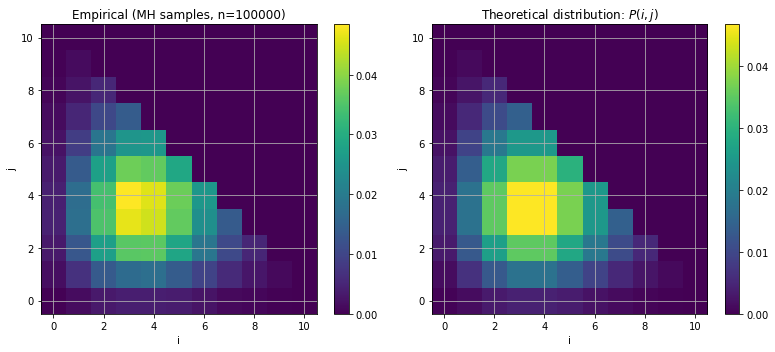

In [376]:
### PLotting joint dstribution
i_vals = X_joint_coord[:,0]
j_vals = X_joint_coord[:,1]

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Initialise fig, ax
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# Compute 2D histogram
Histogram, _, _ = np.histogram2d(i_vals, j_vals, bins=edges, density=True)

### Plot emperical heatmap
im0 = ax[0].imshow(
    Histogram.T, 
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[0].set_title(f"Empirical (MH samples, n={n_sample:.0f})")
ax[0].set_xlabel("i")
ax[0].set_ylabel("j")
ax[0].grid()
fig.colorbar(im0, ax=ax[0])

### Plot theoretical heatmap
im1 = ax[1].imshow(
    P.T,
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[1].set_title(r"Theoretical distribution: $P(i,j)$")
ax[1].set_xlabel("i")
ax[1].set_ylabel("j")
ax[1].grid()
fig.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

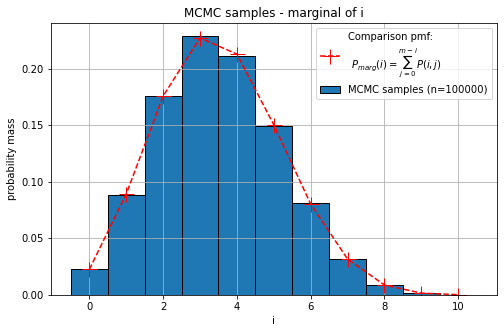

In [377]:
### PLotting marginal distribution

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Plot results
fig, ax = plt.subplots(figsize=(8,5))
#Histogram
ax.grid()
ax.hist(
    i_vals, 
    bins=edges,
    density=True,
    edgecolor='black',
    label= f"MCMC samples (n={n_sample:.0f})"
)
plt.plot(
    xgrid,
    marg_pmf_vals,
    label = ('Comparison pmf:\n'
             r' $P_{marg}(i) = \sum_{j=0}^{m-i} P(i,j)$'),
    color='red', 
    marker='+', 
    markersize=15, 
    linestyle='--'
)

ax.set_xlabel('i')
ax.set_ylabel('probability mass')
ax.set_title('MCMC samples - marginal of i')
ax.legend()
plt.show()

In [378]:
### Chi2 Goodness-of-fit test: creating observed and expected bins
#Observed bins (number of bins: m+1)
obs = np.bincount(i_vals, minlength=m+1)

#Expedted vals (using pmf)
exp = len(i_vals)*marg_pmf_vals

#Checking:
print("Before regrouping bins")
print(f"Sum of obs: {sum(obs)}")
print(f"sum of exp: {sum(exp)}")
print("Observed values:")
print(obs)
print("Expected values:")
print(exp)
print("Is any expected val below 5? (if empty, then no):")
print(exp[exp<5])

### Apply grouping function
obs_g, exp_g = group_bins(obs=obs, exp=exp, threshold=5)

#Checking:
print("After regrouping bins")
print(f"Sum of obs_g: {sum(obs_g)}")
print(f"sum of exp_g: {sum(exp_g)}")
print("Expected values after grouping:")
print(exp_g)
print("Is any expected val below 5? (if empty, then no):")
print(exp_g[exp_g<5])

Before regrouping bins
Sum of obs: 100000
sum of exp: 99999.99999999999
Observed values:
[ 2259  8857 17555 22900 21151 14954  8107  3150   900   155    12]
Expected values:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]
After regrouping bins
Sum of obs_g: 100000
sum of exp_g: 99999.99999999999
Expected values after grouping:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]


In [379]:
### Chi2 Goodness-of-fit test: performning test
df = len(exp_g) - 1
print(f"number of df: {df}")
chi2_stat, p_val = chi2_GOF(obs=obs_g, exp=exp_g, df=df)

print("chi2 test statistic:")
print(chi2_stat)
print("p_val:")
print(p_val)

number of df: 10
chi2 test statistic:
5.552617967373655
p_val:
0.8513468201842503


##### (c)

In [380]:
### Defining conditional probabilities
def P_i_given_j(j, m, A_1):   
    #Generate un-normalised probabilities
    probs = np.array([
        A_1**k / math.factorial(k) for k in range(m-j+1)
    ])
    #Normalise probabilities
    probs /= np.sum(probs)
    return probs

def P_j_given_i(i, m, A_2):
    #Generate un-normalised probabilities
    probs = np.array([
        A_2**k / math.factorial(k) for k in range(m-i+1)
    ])
    #Normalise probabilities
    probs /= np.sum(probs)
    return probs

In [381]:
### Gibbs sampling algorithm for Erlang system 
# Change: sampling  happens in each direction seperately, i+j=m constrain enforced always
# No rejection, sampling happens from conditional probabilities 

def Gibbs_joint_erlang_sys(n_sample, m, A_1, A_2):
    #Convert to int
    n_sample = int(n_sample)

    #Initialise list of combinations of (i,j) given m-values
    pairs = combinations_joint(m)

    ## Step 0)
    #Initialise list for samples
    X = []
    #Initialise state x=(i,j) from proposal function, h(x,y) (uniform from all (i,j) combinations)
    x = h_proposal_joint(pairs)
    X.append(x)

    #Start timing
    start1 = time.time()

    ## Start loop
    for _ in range(n_sample - 1):
        
        #Start from current state
        i,j = X[-1]

        ## 1) Sample new i given j
        #Generate probabilities via P(i|j)
        probs_i_given_j = P_i_given_j(j=j, m=m, A_1=A_1)
        #Draw i from this distribution (using np.random.choice)
        i = np.random.choice(range(m - j + 1), p=probs_i_given_j)

        ## 2) Sample new j given i
        #Generate probabilities via P(j|i)
        probs_j_given_i = P_j_given_i(i=i, m=m, A_2=A_2)
        #Draw i from this distribution (using np.random.choice)
        j = np.random.choice(range(m - i + 1), p=probs_j_given_i)

        ## Save state after both updates
        X.append([i, j])
    
    #end timing
    end1 = time.time()
    runtime1 = end1-start1
    
    return np.array(X), runtime1

In [382]:
### Set params
n_sample = 1e5
m = 10
#A (offered traffic). Value from ex.
A_1 = 4
A_2 = 4

### Run simlation
X_joint_gibbs, runtime_joint_gibbs = Gibbs_joint_erlang_sys(n_sample=n_sample, m=m, A_1=A_1, A_2=A_2)

In [383]:
#Check values
print("Sahpe of samples", np.shape(X_joint_gibbs))
print("min val: ",np.min(X_joint_gibbs), " max val: ", np.max(X_joint_gibbs))
print(f"runtime: {runtime_joint_gibbs:.2f} s")

Sahpe of samples (100000, 2)
min val:  0  max val:  10
runtime: 6.04 s


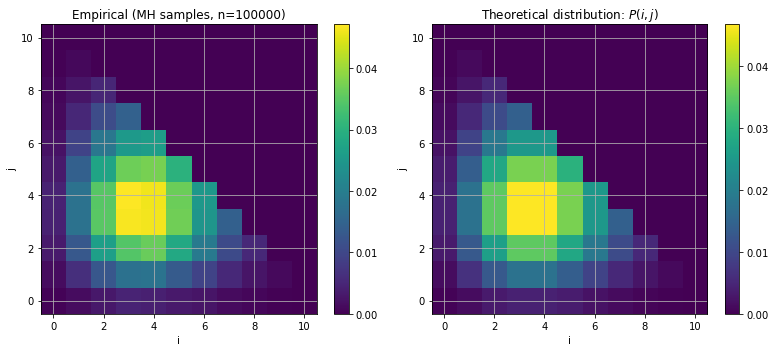

In [384]:
### PLotting joint dstribution
i_vals = X_joint_gibbs[:,0]
j_vals = X_joint_gibbs[:,1]

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Initialise fig, ax
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# Compute 2D histogram
Histogram, _, _ = np.histogram2d(i_vals, j_vals, bins=edges, density=True)

### Plot emperical heatmap
im0 = ax[0].imshow(
    Histogram.T, 
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[0].set_title(f"Empirical (MH samples, n={n_sample:.0f})")
ax[0].set_xlabel("i")
ax[0].set_ylabel("j")
ax[0].grid()
fig.colorbar(im0, ax=ax[0])

### Plot theoretical heatmap
im1 = ax[1].imshow(
    P.T,
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[1].set_title(r"Theoretical distribution: $P(i,j)$")
ax[1].set_xlabel("i")
ax[1].set_ylabel("j")
ax[1].grid()
fig.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

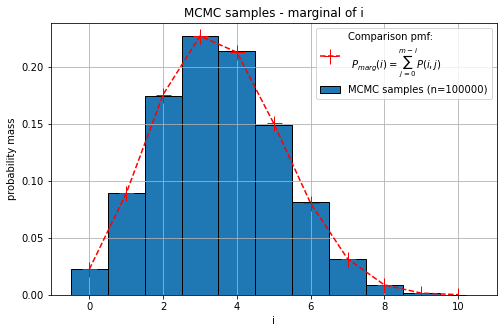

In [385]:
### PLotting marginal distribution

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Plot results
fig, ax = plt.subplots(figsize=(8,5))
#Histogram
ax.grid()
ax.hist(
    i_vals, 
    bins=edges,
    density=True,
    edgecolor='black',
    label= f"MCMC samples (n={n_sample:.0f})"
)
plt.plot(
    xgrid,
    marg_pmf_vals,
    label = ('Comparison pmf:\n'
             r' $P_{marg}(i) = \sum_{j=0}^{m-i} P(i,j)$'),
    color='red', 
    marker='+', 
    markersize=15, 
    linestyle='--'
)

ax.set_xlabel('i')
ax.set_ylabel('probability mass')
ax.set_title('MCMC samples - marginal of i')
ax.legend()
plt.show()

In [386]:
### Chi2 Goodness-of-fit test: creating observed and expected bins
#Observed bins (number of bins: m+1)
obs = np.bincount(i_vals, minlength=m+1)

#Expedted vals (using pmf)
exp = len(i_vals)*marg_pmf_vals

#Checking:
print("Before regrouping bins")
print(f"Sum of obs: {sum(obs)}")
print(f"sum of exp: {sum(exp)}")
print("Observed values:")
print(obs)
print("Expected values:")
print(exp)
print("Is any expected val below 5? (if empty, then no):")
print(exp[exp<5])

### Apply grouping function
obs_g, exp_g = group_bins(obs=obs, exp=exp, threshold=5)

#Checking:
print("After regrouping bins")
print(f"Sum of obs_g: {sum(obs_g)}")
print(f"sum of exp_g: {sum(exp_g)}")
print("Expected values after grouping:")
print(exp_g)
print("Is any expected val below 5? (if empty, then no):")
print(exp_g[exp_g<5])

Before regrouping bins
Sum of obs: 100000
sum of exp: 99999.99999999999
Observed values:
[ 2223  8926 17449 22726 21436 14889  8126  3170   892   156     7]
Expected values:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]
After regrouping bins
Sum of obs_g: 100000
sum of exp_g: 99999.99999999999
Expected values after grouping:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]


In [387]:
### Chi2 Goodness-of-fit test: performning test
df = len(exp_g) - 1
print(f"number of df: {df}")
chi2_stat, p_val = chi2_GOF(obs=obs_g, exp=exp_g, df=df)

print("chi2 test statistic:")
print(chi2_stat)
print("p_val:")
print(p_val)

number of df: 10
chi2 test statistic:
7.655367449012163
p_val:
0.6624592943737304


### Part 3

##### (a)

In [388]:
# Define parameters for bi-variate normal dist.
mu_Xi = 0
mu_Gam = 0
var_Xi = 1
var_Gam =1
rho = 0.5

mu = np.array([mu_Xi, mu_Gam])
cov_mat = np.array([[1, rho], [rho, 1]])

#Draw (xi,gamma) sample from distribution
np.random.seed(43)

xi, gamma = sp.stats.multivariate_normal.rvs(mean=mu, cov=cov_mat)

print(f"xi: {xi:.4f}")
print(f"gamma: {gamma:.4f}")

#Transform into (theta, psi) by log-relation
theta_true = np.exp(xi)
psi_true = np.exp(gamma)

print(f"theta: {theta_true:.4f}")
print(f"psi: {psi_true:.4f}")

xi: 0.2313
gamma: -0.6772
theta: 1.2603
psi: 0.5081


##### (b)

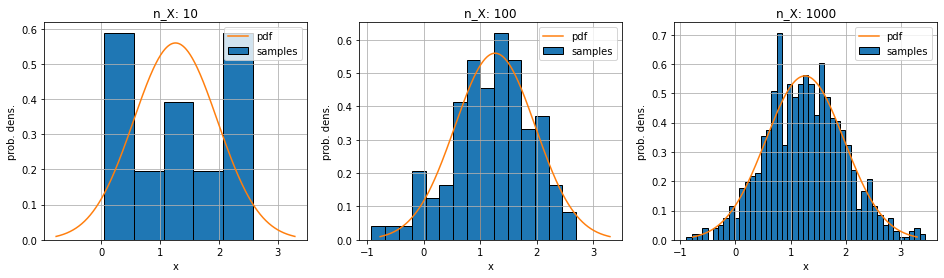

In [389]:
#Draw samples, X, from normal dist., using (theta,psi) as (mean,variance) 
n_samples1 = 10
n_samples2 = 100
n_samples3 = 1000

xgrid = np.linspace(theta_true-4*psi_true, theta_true+4*psi_true, 1000)
#NB: in scipy.stats.norm: scale is std dev = sqrt(var)
norm_vals = sp.stats.norm.pdf(x=xgrid, loc=theta_true, scale=np.sqrt(psi_true))

np.random.seed(44)
X_samples1 = sp.stats.norm.rvs(loc=theta_true, scale=np.sqrt(psi_true), size=n_samples1)
X_samples2 = sp.stats.norm.rvs(loc=theta_true, scale=np.sqrt(psi_true), size=n_samples2)
X_samples3 = sp.stats.norm.rvs(loc=theta_true, scale=np.sqrt(psi_true), size=n_samples3)

#Visualise samples and underlying dist
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16,4))

ax[0].hist(X_samples1, bins=5, edgecolor='black', label='samples', density=True)
ax[0].plot(xgrid, norm_vals, label='pdf')
ax[0].set_title(f"n_X: {n_samples1}")

ax[1].hist(X_samples2, bins=15, edgecolor='black', label='samples', density=True)
ax[1].plot(xgrid, norm_vals, label='pdf')
ax[1].set_title(f"n_X: {n_samples2}")

ax[2].hist(X_samples3, bins=45, edgecolor='black', label='samples', density=True)
ax[2].plot(xgrid, norm_vals, label='pdf')
ax[2].set_title(f"n_X: {n_samples3}")

#For all plots
for i in range(3):
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('prob. dens.')
    ax[i].legend()
    ax[i].grid()

plt.show()

##### (c)

In [390]:
#Define likelihood, posterior, and factored function (their product)
def likelihood(theta, psi, mean, var, n):
    """
    mean and var are sample mean and variance
    n is sample size 
    """
    power = - ((n-1)*var + n*(mean-theta)**2)/(2*psi)
    return psi**(-n/2)*np.exp(power)

def prior(theta, psi, rho):
    """
    rho is correlation between Xi and Gamma
    """
    power = - ( np.log(theta) - 2*rho*np.log(theta)*np.log(psi) + np.log(psi) ) / (2*( 1-rho**2 )) 
    return 1/(theta*psi) * np.exp(power)
    
#Only this one used
def g_post(theta, psi, rho, mean, var, n):
    power1 = - ((n-1)*var + n*(mean-theta)**2)/(2*psi)
    power2 = - ( np.log(theta) - 2*rho*np.log(theta)*np.log(psi) + np.log(psi) ) / (2*( 1-rho**2 )) 

    return 1/(psi**(n/2 + 1)*theta) * np.exp(power1 + power2)

#Only this one used
def g_post_log(theta, psi, rho, mean, var, n):
    power1 = - ((n-1)*var + n*(mean-theta)**2)/(2*psi)
    power2 = - ( np.log(theta) - 2*rho*np.log(theta)*np.log(psi) + np.log(psi) ) / (2*( 1-rho**2 )) 

    return -(n/2 + 1)*np.log(psi) - np.log(theta) + (power1 + power2)

##### (d) + (e)

In [391]:
### Define proposal distribution: bivariate normal distribution centred around current values. No correlation
# absolute values (reflected values)
#Use this one
def h_proposal_post(theta, psi, rho=0):
    mu = np.array([theta, psi])
    cov_mat = np.array([[1, rho], [rho, 1]])
    #Make proposal 
    theta_prop, psi_prop = sp.stats.multivariate_normal.rvs(mean=mu, cov=cov_mat)
    #(and take abs val)
    return np.abs(theta_prop), np.abs(psi_prop) 

# Define 2nd proposal dist.: uniform for both params on [0,10]
def h_proposal_post2(upper_bound=10):
    return upper_bound*sp.stats.uniform.rvs(size=2)

In [392]:
###FOR INSPIRATION
### Metropolis-Hastings algorithm for sampling posterior. 
# Using bi-variate normal dist (no corr) as proposal -_> random walk
def MH_posterior(n_new_samples, n_OG_samples, mean, var, rho):
    
    #Initialise list for samples
    X = []  

    ## Step 0)
    #Initialise state x=(theta,psi)  at (5 ,5)
    theta = 4
    psi = 4
    X.append([theta, psi])

    #Acceptance counter
    accept_count = 0
    #Start timing
    start1 = time.time()

    ## Start loop
    for _ in range(n_new_samples - 1):
        
        #Start from current state
        theta, psi = X[-1]

        ## Step 1)
        #Propose (theta,psi)-vals of candidate state
        theta_prop, psi_prop = h_proposal_post(theta=theta, psi=psi)
        #theta_prop, psi_prop = h_proposal_post2()

        ## Step 2)
        #Compute acceptance probability to go from old -> propopsed state
        #g_y = g_post(theta=theta_prop, psi=psi_prop, rho=rho, mean=mean, var=var, n=n_OG_samples)
        #g_x = g_post(theta=theta, psi=psi, rho=rho, mean=mean, var=var, n=n_OG_samples)
        g_y_log = g_post_log(theta=theta_prop, psi=psi_prop, rho=rho, mean=mean, var=var, n=n_OG_samples)
        g_x_log = g_post_log(theta=theta, psi=psi, rho=rho, mean=mean, var=var, n=n_OG_samples)
        #alpha = min(1, g_y / g_x)
        alpha = min(1, np.exp(g_y_log-g_x_log))
        ## Step 3)
        #If accepted, update state and count acceptance
        if sp.stats.uniform.rvs() <= alpha:
            theta = theta_prop
            psi = psi_prop
            accept_count += 1
        ## Step 4)
        #Otherwise, don't update state

        ## Save state after update attempt
        X.append([theta, psi])
    
    #end timing
    end1 = time.time()
    runtime1 = end1-start1

    return np.array(X), accept_count, runtime1

In [393]:
### Set params
n_new_samples = int(1e4)

mean_samp1 = np.mean(X_samples1)
var_samp1 = np.var(X_samples1, ddof=1)
mean_samp2 = np.mean(X_samples2)
var_samp2 = np.var(X_samples2, ddof=1)
mean_samp3 = np.mean(X_samples3)
var_samp3 = np.var(X_samples3, ddof=1)

print(f"true theta (mean): {theta_true:.3f}")
print(f"true psi (var): {psi_true:.3f}")
print(f"correlation betw. Xi and Gamma (rho): {rho:.2f}")

print(f"n_X1 samples drawn: {n_samples1}")
print(f"sample mean: {mean_samp1:.3f}")
print(f"sample var: {var_samp1:.3f}")
print(f"n_X2 samples drawn: {n_samples2}")
print(f"sample mean: {mean_samp2:.3f}")
print(f"sample var: {var_samp2:.3f}")
print(f"n_X3 samples drawn: {n_samples3}")
print(f"sample mean: {mean_samp3:.3f}")
print(f"sample var: {var_samp3:.3f}")

### Run simlation
X_MH_post_samples1, acc_post1, runtime_post1 = MH_posterior(n_new_samples=n_new_samples, 
                                                       n_OG_samples=n_samples1, mean=mean_samp1, 
                                                       var=var_samp1, rho=rho)
print("1 done")
X_MH_post_samples2, acc_post2, runtime_post2 = MH_posterior(n_new_samples=n_new_samples, 
                                                       n_OG_samples=n_samples2, mean=mean_samp2, 
                                                       var=var_samp2, rho=rho)
print("2 done")
X_MH_post_samples3, acc_post3, runtime_post3 = MH_posterior(n_new_samples=n_new_samples, 
                                                       n_OG_samples=n_samples3, mean=mean_samp3, 
                                                       var=var_samp3, rho=rho)
print("3 done")

true theta (mean): 1.260
true psi (var): 0.508
correlation betw. Xi and Gamma (rho): 0.50
n_X1 samples drawn: 10
sample mean: 1.223
sample var: 0.862
n_X2 samples drawn: 100
sample mean: 1.197
sample var: 0.497
n_X3 samples drawn: 1000
sample mean: 1.254
sample var: 0.511
1 done
2 done
3 done


In [394]:
#Check values
theta_samples1 = X_MH_post_samples1[:,0]
psi_samples1 = X_MH_post_samples1[:,1]
theta_samples2 = X_MH_post_samples2[:,0]
psi_samples2 = X_MH_post_samples2[:,1]
theta_samples3 = X_MH_post_samples3[:,0]
psi_samples3 = X_MH_post_samples3[:,1]

print("Shape of samples", np.shape(X_MH_post_samples1))
print("min val: ",np.min(X_MH_post_samples1), " max val: ", np.max(X_MH_post_samples1))
print(f"acceptance rate1: {acc_post1/n_new_samples}")
print(f"acceptance rate2: {acc_post2/n_new_samples}")
print(f"acceptance rate3: {acc_post3/n_new_samples}")
print(f"runtime1: {runtime_post1:.2f} s")
print(f"runtime2: {runtime_post2:.2f} s")
print(f"runtime3: {runtime_post3:.2f} s")

Shape of samples (10000, 2)
min val:  0.0005762804758989838  max val:  5.14513378011831
acceptance rate1: 0.2242
acceptance rate2: 0.0211
acceptance rate3: 0.0025
runtime1: 1.08 s
runtime2: 1.11 s
runtime3: 1.07 s


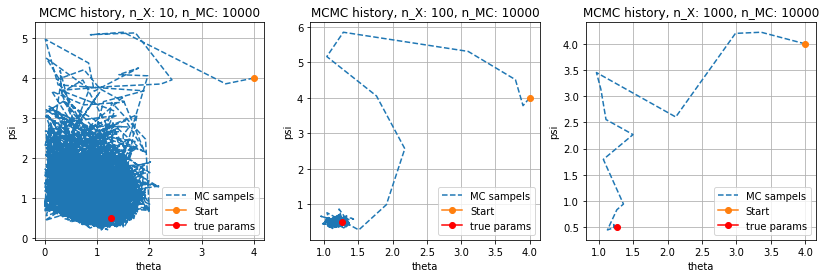

In [395]:
fig, ax =  plt.subplots(nrows=1, ncols=3, figsize=(14,4))


list_thetas = [theta_samples1, theta_samples2, theta_samples3]
list_psis = [psi_samples1, psi_samples2, psi_samples3]
list_nX = [n_samples1, n_samples2, n_samples3]

for i in range(3):
    theta_samples = list_thetas[i]
    psi_samples = list_psis[i]
    n_samples = list_nX[i]

    ax[i].plot(theta_samples, psi_samples, label='MC sampels', linestyle='dashed')
    ax[i].plot(theta_samples[0], psi_samples[0], label='Start', marker='o')
    ax[i].plot(theta_true, psi_true, color='red', label='true params', marker='o')
    ax[i].set_xlabel('theta')
    ax[i].set_ylabel('psi')
    ax[i].legend()
    ax[i].grid()
    ax[i].set_title(f'MCMC history, n_X: {n_samples}, n_MC: {n_new_samples}')

plt.show()

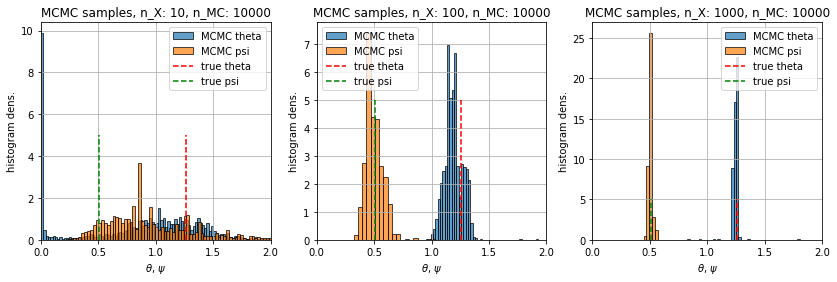

In [396]:
#Edges for histogram bins
#edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

list_nbins = [200, 150, 150]

#Plot results
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,4))

for i in range(3):
    theta_samples = list_thetas[i]
    psi_samples = list_psis[i]
    n_samples = list_nX[i]
    n_bins = list_nbins[i]

    ax[i].grid()
    ax[i].hist(
        theta_samples, 
        bins=n_bins,
        density=True,
        edgecolor='black',
        label= f"MCMC theta",
        alpha=0.7
    )

    ax[i].hist(
        psi_samples, 
        bins=n_bins,
        density=True,
        edgecolor='black',
        label= f"MCMC psi",
        alpha=0.7
    )

    ax[i].vlines(theta_true, ymin=0, ymax=5, label='true theta', color='red', linestyle='--')
    ax[i].vlines(psi_true, ymin=0, ymax=5, label='true psi', color='green', linestyle='--')
    ax[i].set_xlim(0,2)
    ax[i].set_xlabel(r'$\theta$, $\psi$')
    ax[i].set_ylabel('histogram dens.')
    ax[i].set_title(f'MCMC samples, n_X: {n_samples}, n_MC: {n_new_samples}')
    ax[i].legend()

plt.show()

In [397]:
### Print sample mean of the estimated parameter

theta_MC_mean1 = np.mean(theta_samples1)
psi_MC_mean1 = np.mean(psi_samples1)
theta_MC_mean2 = np.mean(theta_samples2)
psi_MC_mean2 = np.mean(psi_samples2)
theta_MC_mean3 = np.mean(theta_samples3)
psi_MC_mean3 = np.mean(psi_samples3)


print(f"true theta (mean): {theta_true:.3f}")
print(f"true psi (var): {psi_true:.3f}")
print("results")
print(f"theta_MC_mean1: {theta_MC_mean1:.3f}")
print(f"psi_MC_mean1: {psi_MC_mean1:.3f}")
print(f"theta_MC_mean2: {theta_MC_mean2:.3f}")
print(f"psi_MC_mean2: {psi_MC_mean2:.3f}")
print(f"theta_MC_mean3: {theta_MC_mean3:.3f}")
print(f"psi_MC_mean3: {psi_MC_mean3:.3f}")

true theta (mean): 1.260
true psi (var): 0.508
results
theta_MC_mean1: 0.844
psi_MC_mean1: 1.006
theta_MC_mean2: 1.193
psi_MC_mean2: 0.505
theta_MC_mean3: 1.243
psi_MC_mean3: 0.516


# Exercise 7

### Part 1

Number of points: 20
Initial route: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Shuffled initial route: [19  3 10 15  9 18 16 14 17 11  6  2 13  8  7  4  5 12  0  1]
Best route:
[12 13  1  5 11  3 18 19  6 17  4 14  9  7 15 16  8  0 10  2]
Best cost:
4.6452004446438915


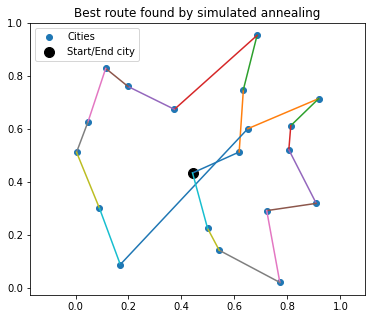

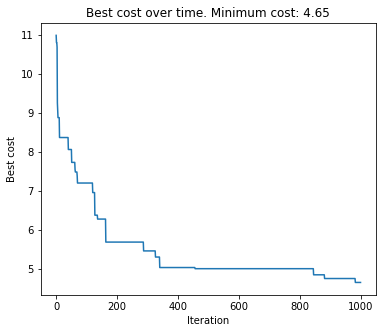

In [398]:
# Exercise 7 - Part 1

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

def route_cost(route, points):
    """
    Compute total cost of a closed route using Euclidean distance.
    """
    total = 0
    n = len(route) # number of cities

    for i in range(n):
        current_city = route[i]
        next_city = route[(i + 1) % n]

        total += np.linalg.norm(points[current_city] - points[next_city])

    return total


def propose_swap(route):
    """
    Create a new route by swapping two randomly chosen cities.
    """
    new_route = route.copy()

    i, j = np.random.choice(len(route), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route


def temperature(k):
    """
    Cooling schedule.
    """
    return 1 / np.sqrt(1 + k)


def simulated_annealing(points, num_iterations):
    """
    Simulated annealing algorithm for the travelling salesman problem.
    """
    #print("Initial points:")
    #print(points)
    print("Number of points:", len(points))
    n = len(points)

    # Start with a random route
    current_route = np.arange(n)
    print("Initial route:", current_route)
    np.random.shuffle(current_route)
    print("Shuffled initial route:", current_route)

    current_cost = route_cost(current_route, points)

    # Store best route found so far
    best_route = current_route.copy()
    best_cost = current_cost

    costs = []

    for k in range(num_iterations):
        T = temperature(k)

        # Generate candidate by swapping two cities
        candidate_route = propose_swap(current_route)
        candidate_cost = route_cost(candidate_route, points)

        delta = candidate_cost - current_cost

        # Accept if candidate is better
        if delta <= 0:
            current_route = candidate_route
            current_cost = candidate_cost

        # Otherwise accept with probability exp(-delta / T)
        else:
            acceptance_probability = np.exp(-delta / T)

            if np.random.rand() < acceptance_probability:
                current_route = candidate_route
                current_cost = candidate_cost

        # Update best solution
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs


# number of cities
n = 20

#point_type = "unit_circle"
point_type = "unit_square"

if point_type == "unit_square":
    points = np.random.rand(n, 2)

elif point_type == "unit_circle":
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)

    points = np.column_stack((
        np.cos(theta),
        np.sin(theta)
    ))

# Run simulated annealing
best_route, best_cost, costs = simulated_annealing(
    points,
    num_iterations=1000
)

print("Best route:")
print(best_route)

print("Best cost:")
print(best_cost)


plt.figure(figsize=(6, 5))

for i in range(len(best_route)):
    p1 = points[best_route[i]]
    p2 = points[best_route[(i + 1) % len(best_route)]]

    plt.plot([p1[0], p2[0]], [p1[1], p2[1]])

plt.scatter(points[:, 0], points[:, 1], label="Cities")
plt.scatter(points[best_route[0], 0], points[best_route[0], 1], color="black", s=100, label="Start/End city")
plt.axis("equal")
plt.title("Best route found by simulated annealing")
plt.legend()
#plt.savefig("best_route.png", dpi=300)
plt.show()


plt.figure(figsize=(6, 5))
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("Best cost over time. Minimum cost: {:.2f}".format(best_cost))
#plt.savefig("best_cost_over_time.png", dpi=300)
plt.show()



### Part 2

Best route:
[ 7  3 11  5 10 19  2 18 14  8 17 16  6 12  0  1 13  9 15  4]
Best cost:
1365


<ipython-input-399-68321492e3d1>:91: RuntimeWarning: overflow encountered in true_divide
  acceptance_probability = np.exp(-delta / T)
<ipython-input-399-68321492e3d1>:91: RuntimeWarning: divide by zero encountered in true_divide
  acceptance_probability = np.exp(-delta / T)


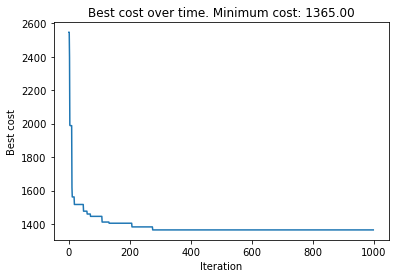

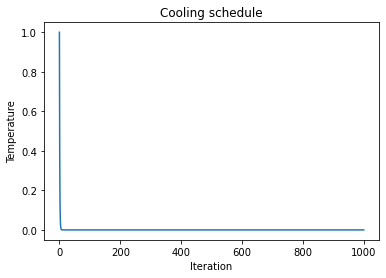

In [399]:
# Exercise 7 - Part 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(10)

def route_cost(route, cost_matrix):
    """
    Computes the total cost of a route (using the cost matrix).

    input: the ordering of the cities. NB the route returns to the starting city. 
    """
    total = 0
    n = len(route)

    for i in range(n):
        current_city = route[i]
        next_city = route[(i + 1) % n] # modulu operator wraps the route back to the starting city
        total += cost_matrix[current_city, next_city]

    return total


def propose_swap(route):
    """
    Generate a new candidate route Yi from the current state Xi by swapping two random cities.
    """
    new_route = route.copy() # copying because we only want to modify the currentroute, if the algorithm accepts the new route

    i, j = np.random.choice(len(route), size=2, replace=False) # a city can not be swapped with itself because of replace=False
    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route

def proposal_2opt(route):
    """
    Create a new route by selecting one random segment and swapping it with its left neighbour.
    Example: If the route is [0, 1, 2, 3, 4] and we select index 2, the new route will be [0, 2, 1, 3, 4].
    """
    new_route = route.copy()

    i = np.random.randint(1, len(route) - 1)
    new_route[i-1], new_route[i] = new_route[i], new_route[i-1]

    return new_route


def temperature(k):
    """
    Cooling scheme:
    """
    #return - k
    #return 1 / np.sqrt(1 + k)
    #return 1 / np.log(2 + k)
    return np.exp(-k)


def simulated_annealing(cost_matrix, num_iterations):
    n = cost_matrix.shape[0] # number of cities

    # Initial route
    current_route = np.arange(n)
    np.random.shuffle(current_route) # shuffle the initial route to start with a random one

    current_cost = route_cost(current_route, cost_matrix)

    best_route = current_route.copy() # initialize best route as the initial route
    best_cost = current_cost          # initialize best cost as the cost of the initial route

    costs = []

    for k in range(num_iterations):
        T = temperature(k)

        candidate_route = propose_swap(current_route)
        #candidate_route = proposal_2opt(current_route)
        candidate_cost = route_cost(candidate_route, cost_matrix)

        # Difference in cost
        delta = candidate_cost - current_cost

        # Accept if better
        if delta <= 0:
            current_route = candidate_route
            current_cost = candidate_cost

        # If not better, still accept with probability exp(-delta / T)
        else:
            acceptance_probability = np.exp(-delta / T)

            if np.random.rand() < acceptance_probability:
                current_route = candidate_route
                current_cost = candidate_cost

        # Save best solution found so far
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs


# Load cost matrix from CSV
cost_matrix = pd.read_csv("cost.csv", header=None).values

best_route, best_cost, costs = simulated_annealing(
    cost_matrix,
    num_iterations=1000
)

print("Best route:")
print(best_route)

print("Best cost:")
print(best_cost)


# Plot improvement of best cost
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("Best cost over time. Minimum cost: {:.2f}".format(best_cost))
#plt.savefig("best_cost_over_time_.png", dpi=300)
plt.show()

# PLot of cooling schedule
plt.plot([temperature(k) for k in range(1000)])
plt.xlabel("Iteration")
plt.ylabel("Temperature")
plt.title("Cooling schedule")
plt.show()

# Exercise 8

### Part 1

In [400]:
import numpy as np
import random
X = np.array([56,101,78,67,93,87,64,72,80,69])
a = -5
b = 5

n = 10
mu = np.mean(X)

def Inverse_EDF(X, p):
    sorted_X = np.sort(X)
    index = int(np.ceil(p * n)) - 1
    return sorted_X[index]

def bootstrap_sample_inverse(X):
    n = len(X)
    return np.array([Inverse_EDF(X, random.uniform(0, 1)) for _ in range(n)])

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(1000)]

accepted = 0
for sample in bootstrap_samples:
    theta = np.mean(sample) - mu
    if a <= theta <= b:
        accepted += 1
print("p = ",(accepted / len(bootstrap_samples))*100, "%")

p =  76.0 %


### Part 2

In [401]:
import numpy as np
import random
random.seed(42)
np.random.seed(42)
n = 15
X = np.array([5,4,9,6,21,17,11,20,7,10,21,15,13,16,8])

k = 1000

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(k)]

var_estimates = []
for sample in bootstrap_samples:
    theta = np.var(sample, ddof=1)
    var_estimates.append(theta)
var_estimates = np.array(var_estimates)
mean_var_estimate = np.mean(var_estimates)
print("Mean of Variance Estimates: ", np.var(X, ddof=1))
variance_estimate = np.var(var_estimates, ddof=1)
print("Estimated Variance of the Variance Estimator: ", variance_estimate)

Mean of Variance Estimates:  34.31428571428571
Estimated Variance of the Variance Estimator:  56.68780166788104


### Part 3

Sample Mean:  4.225954964437149
Sample Median:  1.914960542162116
Estimated Variance of the Sample Mean:  0.2776063673236822
Estimated Variance of the Sample Median:  0.022530789879032093


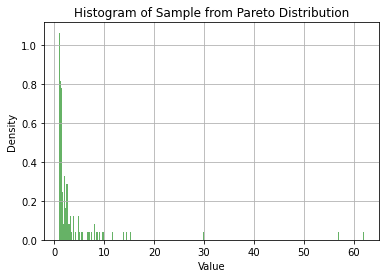

In [402]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy as sp
# Set seed'
random.seed(42)
np.random.seed(42)
n = 200
k = 100

def sample_pareto(beta, k, size=1):
    U = np.random.uniform(0, 1, size=size)
    return k * (U ** (-1/beta))

X = sample_pareto(beta=1, k=1.05, size=200)
X = sp.stats.pareto.rvs(b=1.05, scale=1, size=200, random_state=42)
sample_mean = np.mean(X)
sample_median = np.median(X)
print("Sample Mean: ", sample_mean)
print("Sample Median: ", sample_median)

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(100)]

mean_estimates = []
median_estimates = []
for sample in bootstrap_samples:
    mean_estimates.append(np.mean(sample))
    median_estimates.append(np.median(sample))

mean_var_estimate = np.var(mean_estimates, ddof=1)
median_var_estimate = np.var(median_estimates, ddof=1)
print("Estimated Variance of the Sample Mean: ", mean_var_estimate)
print("Estimated Variance of the Sample Median: ", median_var_estimate)

# plot sample
plt.hist(X, bins=500, density=True, alpha=0.6, color='g')
plt.title('Histogram of Sample from Pareto Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid()
plt.show()